# Assignment 1 - Part 2: Software Effort Estimation

This notebook implements a reproducible workflow to:
- Use two public software effort datasets (`NASA93` and `China`) when both are available
- Audit the raw data before modeling to catch missingness, skewness, outliers, suspicious columns, and high correlations
- Develop and compare traditional regression/ensemble models, tabular foundation models, and explicit dummy baselines
- Apply rigorous validation with nested repeated cross-validation
- Evaluate with MAE, RMSE, MdAE, MASE, and MdASE
- Analyze performance and stability across datasets and outer folds without mixing datasets in the plots


### Study objective and notebook roadmap

The goal of this notebook is to build a complete, reproducible, and methodologically sound workflow for software effort estimation using public datasets. The analysis is designed to satisfy the assignment requirements by selecting at least two datasets, training several predictive models including regression-based methods, evaluating them with rigorous validation, and comparing them with multiple error metrics.

This notebook is structured as an end-to-end experimental pipeline rather than as a collection of isolated code fragments. It begins with dataset acquisition and validation, continues with an exploratory data audit to identify missing values, target skewness, suspicious columns, and strong correlations, and then defines a preprocessing strategy adapted to the types of variables found in each dataset. After that, the notebook evaluates three groups of estimators: traditional models trained on the selected datasets, tabular foundation models that use pre-trained in-context learning behavior, and dummy baselines that provide a minimum reference point. Finally, the results are aggregated, ranked, visualized, and exported in formats that can be reused in the final technical report.

The workflow is designed with three priorities in mind. First, it aims to reduce methodological errors such as target leakage, inappropriate preprocessing, or overly optimistic validation. Second, it aims to make the analysis reproducible by fixing random seeds, exporting intermediate outputs, and organizing the code into reusable helper functions. Third, it aims to make the notebook readable enough that the reader can understand not only what was done, but also why each step was necessary.

Two datasets are used whenever available: `NASA93` and `China`. These datasets differ in size, structure, and feature composition, which makes them useful for comparing model behavior under different data conditions. They are also useful for testing whether newer tabular foundation models behave differently from classical regression and ensemble methods on small and medium-sized effort-estimation datasets. A fallback mechanism is implemented so that the notebook remains robust even if one of the preferred datasets cannot be loaded.


## 1. Setup

Run this notebook from the project folder `assignment1_part2_effort_estimation/`.
It will download raw data snapshots into `data/raw/` and create cleaned CSV files in `data/processed/`.

### Environment, reproducibility, and execution assumptions

This section prepares the notebook environment and defines the constants that control the entire experiment. The imported libraries cover data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), model construction (`scikit-learn` pipelines, preprocessing, regressors, and model selection), and file handling utilities for downloading and storing the datasets.

A key objective here is reproducibility. Fixed random seeds are used so that repeated executions of the notebook remain comparable. The number of outer folds, inner folds, and repeats is also centralized in constants, which makes the validation strategy transparent and easy to modify if needed. Directory paths for raw data, processed data, figures, and output tables are created up front so that the notebook behaves like a self-contained project pipeline rather than a one-off exploratory script.

This section also defines several global parameters that affect later analysis. For example, the correlation threshold used in the exploratory audit is declared here, and the expected model order is fixed so that tables and plots remain consistent across datasets and metrics. By gathering these choices at the top of the notebook, later sections become easier to read and maintain.



In [1]:
from __future__ import annotations

import io
import json
import warnings
import copy
from pathlib import Path
from typing import Dict, Iterable, Tuple
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error
from sklearn.model_selection import GridSearchCV, KFold, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


# ── Tabular Foundation Models (In-Context Learning) ──────────────────
# These models are pre-trained transformers that perform prediction via
# in-context learning. They do NOT require gradient-based training.
# Each model is conditionally enabled only if its library is installed
# AND any required external credentials (API keys) are available.
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path=Path.cwd() / ".env", override=False)

TABPFN_AVAILABLE = False
TABPFN_UNAVAILABLE_REASON = None

try:
    from tabpfn import TabPFNRegressor
    from tabpfn.browser_auth import ensure_license_accepted
    from tabpfn.constants import ModelVersion
    from tabpfn.settings import settings as tabpfn_settings

    def check_tabpfn_local_ready() -> tuple[bool, str | None]:
        token = os.environ.get("TABPFN_TOKEN")
        if not token:
            return False, "TABPFN_TOKEN not found in environment or .env."

        gated_repos = {
            ModelVersion.V2_5: "tabpfn_2_5",
            ModelVersion.V2_6: "tabpfn_2_6",
        }
        model_version = getattr(tabpfn_settings.tabpfn, "model_version", None)
        hf_repo_id = gated_repos.get(model_version)

        if hf_repo_id is None:
            return True, None

        try:
            ensure_license_accepted(hf_repo_id=hf_repo_id)
        except Exception as exc:
            summary = str(exc).strip().splitlines()[0] or exc.__class__.__name__
            return False, summary

        return True, None

    # TabPFN v2+ requires an API key from Prior Labs.
    # Register at https://ux.priorlabs.ai to get one, then set:
    #   os.environ['TABPFN_TOKEN'] = '<your-api-key>'
    TABPFN_AVAILABLE, TABPFN_UNAVAILABLE_REASON = check_tabpfn_local_ready()
    if not TABPFN_AVAILABLE:
        print('WARNING: TabPFN disabled before evaluation.')
        print(f'  → {TABPFN_UNAVAILABLE_REASON}')
        print('  → Check that TABPFN_TOKEN is valid and that the Prior Labs license is accepted.')
        print('  → TabPFN model will be skipped.')
except ImportError:
    TABPFN_UNAVAILABLE_REASON = 'tabpfn is not installed.'
    print('WARNING: tabpfn not installed. TabPFN model will be skipped.')

try:
    from tabicl import TabICLRegressor
    TABICL_AVAILABLE = True
except ImportError:
    TABICL_AVAILABLE = False
    print('WARNING: tabicl not installed. TabICLv2 model will be skipped.')

try:
    from tabdpt import TabDPTRegressor

    # Notebook-local sklearn compatibility shim for upstream tabdpt.
    class SklearnCompatibleTabDPTRegressor(TabDPTRegressor):
        def __init__(
            self,
            inf_batch_size=512,
            normalizer="standard",
            missing_indicators=False,
            clip_sigma=4.0,
            feature_reduction="pca",
            faiss_metric="l2",
            device=None,
            use_flash=True,
            compile=True,
            model_weight_path=None,
            verbose=True,
        ):
            super().__init__(
                inf_batch_size=inf_batch_size,
                normalizer=normalizer,
                missing_indicators=missing_indicators,
                clip_sigma=clip_sigma,
                feature_reduction=feature_reduction,
                faiss_metric=faiss_metric,
                device=device,
                use_flash=use_flash,
                compile=compile,
                model_weight_path=model_weight_path,
                verbose=verbose,
            )
            self.clip_sigma = clip_sigma
            self.model_weight_path = self.path if model_weight_path is None else model_weight_path

    TABDPT_AVAILABLE = True
except ImportError:
    TABDPT_AVAILABLE = False
    print('WARNING: tabdpt not installed. TabDPT model will be skipped.')

# Suppress non-critical warnings from HuggingFace Hub and other libs
warnings.filterwarnings('ignore', message='.*unauthenticated requests.*')
warnings.filterwarnings('ignore', message='.*IProgress not found.*')


C:\Users\05jan\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reproducibility constants
RANDOM_STATE = 42
OUTER_SPLITS = 5
OUTER_REPEATS = 10
INNER_SPLITS = 3
EPSILON = 1e-8
EDA_CORR_THRESHOLD = 0.85
MODEL_ORDER = ["ElasticNet", "RandomForest", "GradientBoosting", "TabPFN", "TabICLv2", "TabDPT", "DummyMean", "DummyMedian"]

MIN_DATASETS = 2
MAX_DATASETS = 2

BASE_DIR = Path.cwd()
DATA_RAW_DIR = BASE_DIR / "data" / "raw"
DATA_PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "figures"

DATASET_CANDIDATES = [
    {
        "name": "NASA93",
        "url": "https://zenodo.org/records/268419/files/nasa93.arff?download=1",
        "raw_name": "nasa93.arff",
        "format": "arff",
        "target": "act_effort",
        "drop": ["recordnumber"],
        "drop_reasons": {
            "recordnumber": "Unique project identifier without predictive value.",
        },
    },
    {
        "name": "China",
        "url": "https://zenodo.org/records/268446/files/china.arff?download=1",
        "raw_name": "china.arff",
        "format": "arff",
        "target": "Effort",
        "drop": ["ID", "N_effort", "PDR_AFP", "PDR_UFP", "NPDR_AFP", "NPDU_UFP"],
        "drop_reasons": {
            "ID": "Identifier without predictive value.",
            "N_effort": "Alternative effort target not available at prediction time.",
            "PDR_AFP": "Derived from Effort / AFP and leaks the target.",
            "PDR_UFP": "Derived from Effort / UFP and leaks the target.",
            "NPDR_AFP": "Derived from N_effort / AFP and leaks an alternative target.",
            "NPDU_UFP": "Derived from N_effort / UFP and leaks an alternative target.",
        },
    },
    {
        "name": "COC81",
        "url": "https://zenodo.org/records/268424/files/coc81-dem.arff?download=1",
        "raw_name": "coc81-dem.arff",
        "format": "arff",
        "target": "effort",
        "drop": ["id", "defects"],
        "drop_reasons": {
            "id": "Identifier without predictive value.",
            "defects": "Post-delivery outcome excluded from effort prediction.",
        },
    },
]

for directory in [DATA_RAW_DIR, DATA_PROCESSED_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


## 2. Data Acquisition and Loading

The helpers below snapshot candidate datasets and load them with a robust fallback strategy.
They try `NASA93`, then `China`, then `COC81`, skipping failures until at least two datasets are loaded.
When `NASA93` and `China` load successfully, they are the datasets used throughout the analysis; `COC81` remains a technical fallback only.
Compatibility note: PROMISE ARFF variants are normalized for non-standard headers and whitespace-delimited rows.

### Data acquisition strategy and loading helpers

The datasets used in this study are retrieved automatically from public PROMISE/Zenodo sources. Instead of assuming that every source will always be available in the same format, the notebook implements a robust loading strategy that can handle dataset availability issues and formatting inconsistencies. This is particularly useful for older software engineering datasets, which are often distributed as ARFF files with small structural irregularities.

Several helper functions are defined in the next code cell. `download_dataset()` is responsible for downloading a dataset only when it is not already present locally, which avoids unnecessary repeated downloads and makes the workflow more efficient. `_sanitize_arff_text()` corrects non-standard PROMISE headers such as `@class` declarations that should behave as `@attribute` entries. `_split_arff_sections()`, `_extract_attributes()`, `_tokenize_data_row()`, and related helpers are used to parse the raw ARFF content in a defensive way so that slightly malformed files can still be loaded into data frames.

The function `load_arff()` performs the actual parsing of the ARFF content and converts it into a tabular structure. `snapshot_and_load()` combines downloading and parsing into a single step. `load_available_datasets()` applies the candidate selection logic: it attempts to load the preferred datasets in order, validates whether they are usable for modeling, and keeps loading until the minimum required number of datasets is reached. Finally, `get_modeling_frame()` separates predictors from the target and removes columns that should not be used for learning.

This design is intentionally more careful than a simple `read_csv()` or direct file load because the notebook aims to be robust across environments and dataset versions. It also makes the loading process auditable: the reader can clearly see which dataset was selected, which columns were excluded, and why those exclusions were necessary.


In [3]:
RATING_ORDER = ["vl", "l", "n", "h", "vh", "xh"]
RATING_SET = set(RATING_ORDER)


def download_dataset(url: str, out_path: Path) -> Path:
    """Download a file only if it is not present locally."""
    if not out_path.exists():
        print(f"Downloading {out_path.name}...")
        urlretrieve(url, out_path)
    else:
        print(f"Using cached file: {out_path.name}")
    return out_path


def _sanitize_arff_text(raw_text: str) -> str:
    """
    Normalize non-standard PROMISE headers such as:
    @class months numeric  ->  @attribute months numeric
    """
    cleaned = []
    for line in raw_text.splitlines():
        stripped = line.strip()
        if stripped.lower().startswith("@class "):
            leading_ws = line[: len(line) - len(line.lstrip())]
            cleaned.append(f"{leading_ws}@attribute {stripped[7:]}")
        else:
            cleaned.append(line)
    return "\n".join(cleaned) + "\n"


def _split_arff_sections(arff_text: str) -> tuple[list[str], list[tuple[int, str]]]:
    """Return header lines and (line_no, data_line) for non-empty data rows."""
    lines = arff_text.splitlines()
    header_lines = []
    data_lines: list[tuple[int, str]] = []
    in_data = False

    for i, line in enumerate(lines, start=1):
        stripped = line.strip()
        if not in_data:
            header_lines.append(line)
            if stripped.lower() == "@data":
                in_data = True
            continue

        if not stripped or stripped.startswith("%"):
            continue
        data_lines.append((i, stripped))

    return header_lines, data_lines


def _detect_data_delimiter(data_lines: list[tuple[int, str]]) -> str:
    if not data_lines:
        return "comma"
    return "comma" if "," in data_lines[0][1] else "whitespace"


def _parse_attribute_definition(line: str) -> dict:
    """Parse one ARFF @attribute definition."""
    raw = line.strip()[len("@attribute "):].strip()
    parts = raw.split(None, 1)
    if len(parts) < 2:
        raise ValueError(f"Malformed @attribute line: {line}")

    name = parts[0].strip("'\"")
    type_spec = parts[1].strip()
    lower_type = type_spec.lower()

    if type_spec.startswith("{") and type_spec.endswith("}"):
        kind = "nominal"
        values = [v.strip() for v in type_spec[1:-1].split(",")]
    elif lower_type in {"numeric", "real", "integer"}:
        kind = "numeric"
        values = None
    else:
        kind = "string"
        values = None

    return {"name": name, "type_spec": type_spec, "kind": kind, "values": values}


def _extract_attributes(header_lines: list[str]) -> list[dict]:
    attrs = []
    for line in header_lines:
        if line.strip().lower().startswith("@attribute "):
            attrs.append(_parse_attribute_definition(line))
    return attrs


def _tokenize_data_row(raw_row: str, delimiter: str) -> list[str]:
    if delimiter == "comma":
        return [token.strip() for token in raw_row.split(",")]
    return raw_row.split()


def load_arff(path: Path) -> pd.DataFrame:
    """Robust ARFF loader supporting comma and whitespace data rows."""
    raw_text = path.read_text(encoding="utf-8", errors="ignore")
    raw_lower = raw_text.lower()
    if "@relation" not in raw_lower or "@data" not in raw_lower:
        raise ValueError(f"File does not look like ARFF: {path}")

    sanitized_text = _sanitize_arff_text(raw_text)
    header_lines, data_lines = _split_arff_sections(sanitized_text)
    attributes = _extract_attributes(header_lines)
    if not attributes:
        raise ValueError(f"No @attribute definitions found in {path}")

    delimiter = _detect_data_delimiter(data_lines)
    expected_fields = len(attributes)

    rows = []
    for line_no, raw_row in data_lines:
        tokens = _tokenize_data_row(raw_row, delimiter)
        if len(tokens) != expected_fields:
            raise ValueError(
                f"ARFF row width mismatch at line {line_no}: "
                f"expected {expected_fields}, got {len(tokens)}. Row: {raw_row}"
            )
        rows.append(tokens)

    df = pd.DataFrame(rows, columns=[attr["name"] for attr in attributes])

    # Normalize missing markers and cast numeric columns.
    df = df.replace("?", np.nan)
    for attr in attributes:
        if attr["kind"] == "numeric":
            df[attr["name"]] = pd.to_numeric(df[attr["name"]], errors="coerce")

    return df


def snapshot_and_load(dataset_name: str, cfg: dict) -> pd.DataFrame:
    raw_path = DATA_RAW_DIR / cfg["raw_name"]
    download_dataset(cfg["url"], raw_path)

    dataset_format = cfg.get("format", "arff").lower()
    if dataset_format != "arff":
        raise ValueError(f"Unsupported dataset format: {dataset_format}")

    df = load_arff(raw_path)
    out_csv = DATA_PROCESSED_DIR / f"{dataset_name.lower()}_clean.csv"
    df.to_csv(out_csv, index=False)
    return df


def _validate_dataset_for_modeling(df: pd.DataFrame, cfg: dict) -> None:
    target = cfg["target"]
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found")
    if len(df) < 10:
        raise ValueError("Dataset has too few rows for cross-validation")


def load_available_datasets(
    candidates: list[dict],
    min_required: int = 2,
    max_selected: int = 2,
) -> tuple[dict[str, dict], pd.DataFrame]:
    """
    Attempt candidate datasets in order and keep successful loads.
    Returns selected datasets map and a load report dataframe.
    """
    selected: dict[str, dict] = {}
    report_rows = []

    for cfg in candidates:
        name = cfg["name"]
        try:
            df = snapshot_and_load(name, cfg)
            _validate_dataset_for_modeling(df, cfg)

            selected[name] = {"cfg": cfg, "df": df}
            report_rows.append(
                {
                    "dataset": name,
                    "status": "loaded",
                    "rows": int(df.shape[0]),
                    "columns": int(df.shape[1]),
                    "error": "",
                }
            )
        except Exception as exc:
            report_rows.append(
                {
                    "dataset": name,
                    "status": "failed",
                    "rows": 0,
                    "columns": 0,
                    "error": str(exc),
                }
            )

        if len(selected) >= max_selected:
            break

    report_df = pd.DataFrame(report_rows)
    report_df.to_csv(BASE_DIR / "dataset_load_report.csv", index=False)

    if len(selected) < min_required:
        loaded = list(selected.keys())
        raise RuntimeError(
            f"Only {len(selected)} dataset(s) loaded ({loaded}). "
            f"At least {min_required} required. See dataset_load_report.csv for details."
        )

    return selected, report_df




def get_modeling_frame(df: pd.DataFrame, cfg: dict) -> tuple[pd.DataFrame, pd.Series, list[str]]:
    target_col = cfg["target"]
    drop_cols = [c for c in cfg.get("drop", []) if c in df.columns]
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col].astype(float)
    return X, y, drop_cols


In [4]:
selected_datasets, dataset_load_report = load_available_datasets(
    DATASET_CANDIDATES,
    min_required=MIN_DATASETS,
    max_selected=MAX_DATASETS,
)

selected_dataset_configs = {name: payload["cfg"] for name, payload in selected_datasets.items()}
datasets_df = {name: payload["df"] for name, payload in selected_datasets.items()}

print("Dataset load report:")
display(dataset_load_report)

print("Selected datasets:", list(datasets_df.keys()))
for name, df in datasets_df.items():
    print(f"{name}: shape={df.shape}")
    display(df.head())



Using cached file: nasa93.arff
Using cached file: china.arff
Dataset load report:


,dataset,status,rows,columns,error
0,NASA93,loaded,93,24,
1,China,loaded,499,19,


Selected datasets: ['NASA93', 'China']
NASA93: shape=(93, 24)


,recordnumber,projectname,cat2,forg,center,year,mode,rely,data,cplx,...,acap,aexp,pcap,vexp,lexp,modp,tool,sced,equivphyskloc,act_effort
0,1,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,25.9,117.6
1,2,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,24.6,117.6
2,3,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,7.7,31.2
3,4,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,8.2,36.0
4,5,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,9.7,25.2


China: shape=(499, 19)


,ID,AFP,Input,Output,Enquiry,File,Interface,Added,Changed,Deleted,PDR_AFP,PDR_UFP,NPDR_AFP,NPDU_UFP,Resource,Dev.Type,Duration,N_effort,Effort
0,1,1587,774,260,340,128,0,1502,0,0,4.7,5.0,4.7,5.0,4,0,4.0,7490,7490
1,2,260,9,4,3,193,41,51,138,61,16.0,16.6,16.0,16.6,2,0,17.0,4150,4150
2,3,152,25,33,28,42,35,163,0,0,4.4,4.1,4.4,4.1,1,0,9.0,668,668
3,4,252,151,28,8,39,0,69,153,4,12.8,14.3,15.5,17.3,1,0,4.0,3901,3238
4,5,292,93,0,194,20,0,0,307,0,10.3,9.8,12.4,11.7,1,0,13.0,3607,2994


### Interpreting the dataset loading report

The output produced below serves as the first validation checkpoint of the experiment. It confirms which datasets were successfully loaded, how many rows and columns each one contains, and whether the preferred combination (`NASA93` and `China`) is available. This matters because the rest of the notebook assumes that at least two valid datasets have been selected and that each one contains a clearly identifiable target variable.

The preview of the first rows is not included only for convenience. It is useful for checking whether feature names look sensible, whether categorical ratings are represented consistently, whether obvious identifiers are present, and whether any suspicious columns appear to encode information derived from the target. In software effort estimation datasets, this last point is especially important because effort-derived productivity variables can create target leakage if they are mistakenly included as predictors.

The loading report also helps verify that the fallback logic behaves as expected. `COC81` is kept only as a technical fallback candidate in case one of the preferred datasets cannot be loaded, but the main analysis is designed around `NASA93` and `China` whenever both are available. Making this logic explicit improves the transparency of dataset selection and prevents confusion about which datasets are actually used in the rest of the notebook.

## 3. Exploratory Data Audit

The audit below checks missingness, target skewness, outliers, excluded columns, and strong correlations among numeric predictors **after** leakage-prone variables are removed from the modeling frame.

Before any model is trained, the notebook performs a compact but targeted exploratory audit of each dataset. The purpose of this audit is not to produce a large descriptive study, but to identify the data characteristics that may directly affect the modeling strategy. In particular, the audit focuses on missingness, the shape and skewness of the target variable, outliers in the target, the number and type of predictors available after column exclusions, and strong pairwise correlations among numerical predictors.

The helper function `summarize_missing_values()` reports which columns contain missing entries and how large the missingness proportion is. This information is needed because missing values influence the choice of imputation strategy and may also reveal data quality issues. The function `find_high_correlation_pairs()` identifies highly correlated numerical predictors, which is particularly relevant for linear models because strong multicollinearity can make coefficient estimates unstable and harder to interpret.

In addition to missingness and correlations, the code computes summary statistics of the target variable, including mean, median, skewness, and an outlier count based on the interquartile range rule. This is useful because effort data are often strongly right-skewed: a small number of very large projects can dominate the distribution. If that happens, MAE, RMSE, and MdAE may react differently, and a logarithmic transformation of the target can become a sensible modeling choice.

A crucial detail is that the audit is performed after removing leakage-prone predictors from the modeling frame. This is particularly important for the `China` dataset, where some columns are directly derived from effort and therefore must not be used as inputs for predictive modeling. By making leakage checks part of the audit stage, the notebook reduces the risk of reporting artificially optimistic performance.


=== NASA93 audit ===
Rows=93, columns=24, predictors after exclusions=22
Numeric predictors=2, categorical predictors=20
Target skewness=4.257 | IQR outliers=10
Excluded columns before modeling:


,column,reason
0,recordnumber,Unique project identifier without predictive v...


Missing values: none detected in the current snapshot.
No numeric predictor pairs above |corr| >= 0.85 after exclusions.


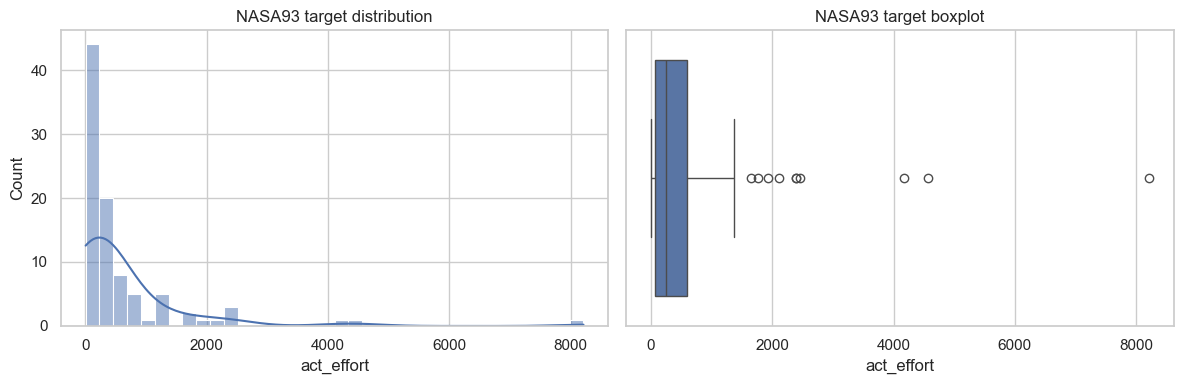

=== China audit ===
Rows=499, columns=19, predictors after exclusions=12
Numeric predictors=12, categorical predictors=0
Target skewness=3.929 | IQR outliers=54
Excluded columns before modeling:


,column,reason
0,ID,Identifier without predictive value.
1,N_effort,Alternative effort target not available at pre...
2,PDR_AFP,Derived from Effort / AFP and leaks the target.
3,PDR_UFP,Derived from Effort / UFP and leaks the target.
4,NPDR_AFP,Derived from N_effort / AFP and leaks an alter...
5,NPDU_UFP,Derived from N_effort / UFP and leaks an alter...


Missing values: none detected in the current snapshot.
Top numeric predictor pairs above |corr| >= 0.85:


,feature_a,feature_b,abs_corr
0,AFP,Added,0.933307
1,AFP,Input,0.929968
2,AFP,File,0.914711
3,Input,Added,0.902650
4,File,Added,0.879229


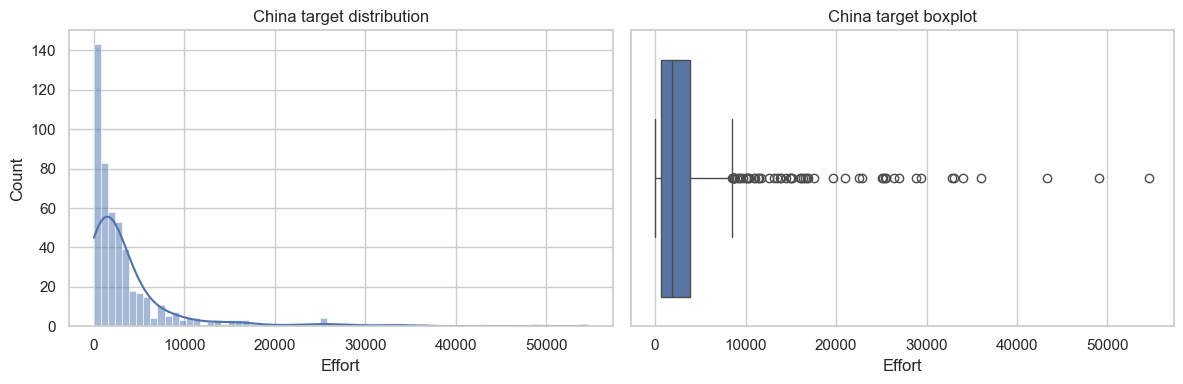

Combined EDA summary:


,dataset,rows,columns,predictors_after_drop,numeric_predictors,categorical_predictors,missing_cells,target_mean,target_median,target_skew,target_iqr,iqr_outliers
0,NASA93,93,24,22,2,20,0,624.4118,252.0,4.2570,530.0,10
1,China,499,19,12,12,0,0,3921.0481,1829.0,3.9287,3123.0,54


In [5]:
def summarize_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    missing_df = (
        df.isna()
        .sum()
        .rename("missing_count")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    missing_df["missing_pct"] = missing_df["missing_count"] / len(df)
    missing_df = missing_df[missing_df["missing_count"] > 0].sort_values(
        ["missing_count", "column"], ascending=[False, True]
    )
    return missing_df.reset_index(drop=True)


def find_high_correlation_pairs(X: pd.DataFrame, threshold: float = EDA_CORR_THRESHOLD) -> pd.DataFrame:
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) < 2:
        return pd.DataFrame(columns=["feature_a", "feature_b", "abs_corr"])

    corr = X[numeric_cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    pairs = []
    for col in upper.columns:
        strong_pairs = upper.index[upper[col] >= threshold].tolist()
        for row_name in strong_pairs:
            pairs.append(
                {
                    "feature_a": row_name,
                    "feature_b": col,
                    "abs_corr": float(upper.loc[row_name, col]),
                }
            )

    if not pairs:
        return pd.DataFrame(columns=["feature_a", "feature_b", "abs_corr"])

    return pd.DataFrame(pairs).sort_values("abs_corr", ascending=False).reset_index(drop=True)


eda_rows = []

for dataset_name, cfg in selected_dataset_configs.items():
    df = datasets_df[dataset_name].copy()
    X, y, drop_cols = get_modeling_frame(df, cfg)

    predictor_numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    predictor_categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    missing_df = summarize_missing_values(df)
    corr_pairs_df = find_high_correlation_pairs(X)

    q1 = y.quantile(0.25)
    q3 = y.quantile(0.75)
    iqr_value = q3 - q1
    lower_bound = q1 - 1.5 * iqr_value
    upper_bound = q3 + 1.5 * iqr_value
    outlier_count = int(((y < lower_bound) | (y > upper_bound)).sum())

    eda_rows.append(
        {
            "dataset": dataset_name,
            "rows": int(len(df)),
            "columns": int(df.shape[1]),
            "predictors_after_drop": int(X.shape[1]),
            "numeric_predictors": int(len(predictor_numeric_cols)),
            "categorical_predictors": int(len(predictor_categorical_cols)),
            "missing_cells": int(df.isna().sum().sum()),
            "target_mean": float(y.mean()),
            "target_median": float(y.median()),
            "target_skew": float(y.skew()),
            "target_iqr": float(iqr_value),
            "iqr_outliers": outlier_count,
        }
    )

    print(f"=== {dataset_name} audit ===")
    print(f"Rows={len(df)}, columns={df.shape[1]}, predictors after exclusions={X.shape[1]}")
    print(f"Numeric predictors={len(predictor_numeric_cols)}, categorical predictors={len(predictor_categorical_cols)}")
    print(f"Target skewness={y.skew():.3f} | IQR outliers={outlier_count}")

    if drop_cols:
        exclusion_df = pd.DataFrame(
            {
                "column": drop_cols,
                "reason": [cfg.get("drop_reasons", {}).get(col, "Excluded before modeling") for col in drop_cols],
            }
        )
        print("Excluded columns before modeling:")
        display(exclusion_df)

    if missing_df.empty:
        print("Missing values: none detected in the current snapshot.")
    else:
        print("Missing values by column:")
        display(missing_df)

    if corr_pairs_df.empty:
        print(f"No numeric predictor pairs above |corr| >= {EDA_CORR_THRESHOLD:.2f} after exclusions.")
    else:
        print(f"Top numeric predictor pairs above |corr| >= {EDA_CORR_THRESHOLD:.2f}:")
        display(corr_pairs_df.head(10))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(y, kde=True, ax=axes[0])
    axes[0].set_title(f"{dataset_name} target distribution")
    axes[0].set_xlabel(cfg["target"])

    sns.boxplot(x=y, ax=axes[1])
    axes[1].set_title(f"{dataset_name} target boxplot")
    axes[1].set_xlabel(cfg["target"])

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"eda_target_{dataset_name.lower()}.png", dpi=150)
    plt.show()

eda_summary_df = pd.DataFrame(eda_rows).round(4)
print("Combined EDA summary:")
display(eda_summary_df)


### What to look for in the audit outputs

When reviewing the audit tables below, three aspects are especially important. First, check whether the target appears strongly right-skewed, because that supports the use of a logarithmic target transformation during model fitting. Second, inspect whether any predictors show unusually strong correlation with the target or with each other, since that may affect model behavior and interpretability. Third, verify that the excluded columns in `China` are indeed leakage-prone effort derivatives and therefore should not be used as predictors.

The audit is not intended to eliminate every issue automatically. Instead, it provides evidence that later preprocessing and modeling decisions are justified by the observed characteristics of the data.


## 4. Preprocessing Design

- Numerical variables: median imputation
- Ordered categorical ratings (e.g., `vl < l < n < h < vh < xh`): ordinal encoding
- Remaining categorical variables: one-hot encoding
- China removes leakage-prone effort derivatives before modeling (`PDR_*`, `NPDR_*`, `NPDU_*`, `N_effort`)
- Target skewness control: the main tuned models use `log1p(y)` internally via `TransformedTargetRegressor`, while scoring and final metrics stay on the original effort scale

The preprocessing strategy is deliberately adapted to the structure of software engineering datasets rather than applying a single generic transformation to all variables. The next code cell begins by separating predictors into three groups: numerical variables, ordinal categorical variables, and nominal categorical variables. This is done by `split_feature_types()`, which inspects the observed values of non-numeric columns and treats a variable as ordinal when its categories follow the standard COCOMO-style rating scale (`vl < l < n < h < vh < xh`).

This distinction matters because ordinal and nominal variables should not be encoded in the same way. If an ordered rating scale is represented as one-hot variables, its natural order is lost. Conversely, if a nominal variable is encoded ordinally, the model may incorrectly interpret arbitrary category codes as meaningful magnitudes. The notebook therefore uses ordinal encoding only when the data genuinely support that interpretation.

The function `build_preprocessor()` constructs a `ColumnTransformer` that applies the appropriate preprocessing pipeline to each variable type. Numerical variables are imputed with the median, which is robust to skewness and outliers. They are also standardized when the downstream model is linear, because linear models such as ElasticNet are sensitive to predictor scale. Ordered categorical variables are imputed with the most frequent category and then ordinally encoded according to the predefined rating order. Remaining nominal categorical variables are imputed with the most frequent value and one-hot encoded so that the model can use them without imposing an artificial order.

This section also reflects an important modeling principle: all preprocessing is embedded inside the pipeline. That means imputers, scalers, and encoders are fitted only on the training data within each fold of cross-validation. This prevents information leakage from the validation fold into the training transformations and makes the evaluation much more trustworthy than applying preprocessing once to the full dataset before validation.


In [6]:
def split_feature_types(X: pd.DataFrame) -> Tuple[list, list, list]:
    """
    Return numeric, ordinal-categorical, and nominal-categorical columns.
    A categorical column is treated as ordinal when all observed values belong to
    the standard COCOMO rating scale.
    """
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    ordinal_cols = []
    nominal_cols = []

    for col in categorical_cols:
        values = set(str(v) for v in X[col].dropna().unique())
        if values and values.issubset(RATING_SET):
            ordinal_cols.append(col)
        else:
            nominal_cols.append(col)

    return numeric_cols, ordinal_cols, nominal_cols


def build_preprocessor(X: pd.DataFrame, for_linear: bool) -> ColumnTransformer:
    numeric_cols, ordinal_cols, nominal_cols = split_feature_types(X)

    transformers = []

    if numeric_cols:
        numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
        if for_linear:
            numeric_steps.append(("scaler", StandardScaler()))
        transformers.append(("num", Pipeline(steps=numeric_steps), numeric_cols))

    if ordinal_cols:
        transformers.append(
            (
                "ord",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "encoder",
                            OrdinalEncoder(
                                categories=[RATING_ORDER] * len(ordinal_cols),
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                            ),
                        ),
                    ]
                ),
                ordinal_cols,
            )
        )

    if nominal_cols:
        transformers.append(
            (
                "nom",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]
                ),
                nominal_cols,
            )
        )

    return ColumnTransformer(transformers=transformers, remainder="drop")



### Why preprocessing is embedded in the pipeline

A critical implementation detail is that imputation, scaling, and encoding are all performed inside the modeling pipeline rather than in separate preprocessing steps applied to the full dataset. This ensures that every preprocessing transformation is learned only from the training portion of each fold. As a result, the validation process remains fair and does not leak information from the test fold into the fitted preprocessing steps.

This design is especially important in small datasets, where even subtle leakage can lead to noticeably optimistic performance estimates.

## 5. Models and Hyperparameter Spaces

The workflow compares three tuned traditional regressors, three tabular foundation models when their dependencies are available, and two explicit baselines:
1. `ElasticNet` (regression-based requirement)
2. `RandomForestRegressor`
3. `GradientBoostingRegressor`
4. `TabPFNRegressor`
5. `TabICLRegressor` / `TabICLv2`
6. `TabDPTRegressor`
7. `DummyRegressor(strategy="mean")`
8. `DummyRegressor(strategy="median")`

### Model selection, target transformation, and hyperparameter search space

The notebook compares models from three methodological families. The first family contains traditional supervised regressors trained specifically on each outer training fold. `ElasticNet` satisfies the requirement to include a regression-based approach and provides a regularized linear reference model. `RandomForestRegressor` and `GradientBoostingRegressor` are tree-based ensembles that can capture non-linear relationships and interactions between predictors more naturally than a purely linear model.

The second family contains tabular foundation models: `TabPFN`, `TabICLv2`, and `TabDPT`. These models are pre-trained for tabular prediction and are used here in an in-context or zero-/few-shot style. Instead of searching a dataset-specific hyperparameter grid, they receive the fold's training data through their fitting/prediction interface and use their pre-trained prior to produce predictions for the held-out fold. This makes them especially relevant for software effort estimation, where public datasets such as `NASA93` are small and ordinary model tuning can be unstable.

The helper function `wrap_target_regressor()` applies a logarithmic transformation to the target through `TransformedTargetRegressor`. This is done with `log1p()` and its inverse `expm1()` so that the model is fitted on a transformed effort scale while predictions are automatically returned to the original scale. This design is useful when effort distributions are right-skewed, because the transformation reduces the dominance of very large projects while preserving interpretability of the final metrics.

`prefix_param_grid()` rewrites hyperparameter names so that they can be passed correctly through the `TransformedTargetRegressor` wrapper. `make_model_pipelines()` then builds the full estimator specification for each available model. The traditional models receive explicit hyperparameter grids and are tuned later with `GridSearchCV`. The tabular foundation models and dummy baselines have `param_grid=None`, which tells the evaluation function to fit them directly on each outer training fold without an inner hyperparameter search.

The baselines `DummyMean` and `DummyMedian` are intentionally simple. They do not learn patterns from the predictors; instead, they always predict a constant value derived from the training fold. Their role is methodological rather than competitive: they provide a minimum standard that every useful model should surpass. If a sophisticated model fails to beat these baselines consistently, its practical value for effort estimation becomes questionable.


In [7]:
def wrap_target_regressor(regressor) -> TransformedTargetRegressor:
    return TransformedTargetRegressor(
        regressor=regressor,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


def prefix_param_grid(param_grid: dict) -> dict:
    return {f"regressor__{key}": values for key, values in param_grid.items()}


def make_model_pipelines(X: pd.DataFrame, random_state: int = 42) -> Dict[str, dict]:
    pre_linear = build_preprocessor(X, for_linear=True)
    pre_tree = build_preprocessor(X, for_linear=False)

    elastic_pipeline = Pipeline(
        steps=[
            ("preprocessor", pre_linear),
            ("model", ElasticNet(max_iter=20000, random_state=random_state)),
        ]
    )

    rf_pipeline = Pipeline(
        steps=[
            ("preprocessor", pre_tree),
            ("model", RandomForestRegressor(random_state=random_state, n_jobs=-1)),
        ]
    )

    gbr_pipeline = Pipeline(
        steps=[
            ("preprocessor", pre_tree),
            ("model", GradientBoostingRegressor(random_state=random_state)),
        ]
    )

    model_specs = {
        "ElasticNet": {
            "estimator": wrap_target_regressor(elastic_pipeline),
            "param_grid": prefix_param_grid(
                {
                    "model__alpha": [0.001, 0.01, 0.1, 1.0],
                    "model__l1_ratio": [0.1, 0.5, 0.9],
                }
            ),
        },
        "RandomForest": {
            "estimator": wrap_target_regressor(rf_pipeline),
            "param_grid": prefix_param_grid(
                {
                    "model__n_estimators": [300, 600],
                    "model__max_depth": [None, 8, 16],
                    "model__min_samples_leaf": [1, 3, 5],
                    "model__max_features": ["sqrt", 0.6],
                }
            ),
        },
        "GradientBoosting": {
            "estimator": wrap_target_regressor(gbr_pipeline),
            "param_grid": prefix_param_grid(
                {
                    "model__n_estimators": [200, 400],
                    "model__learning_rate": [0.03, 0.05, 0.1],
                    "model__max_depth": [2, 3, 4],
                    "model__subsample": [0.7, 1.0],
                }
            ),
        },
        "DummyMean": {
            "estimator": DummyRegressor(strategy="mean"),
            "param_grid": None,
        },
        "DummyMedian": {
            "estimator": DummyRegressor(strategy="median"),
            "param_grid": None,
        },
    }


    # ── Tabular Foundation Models (In-Context Learning) ──────────────
    # These models are pre-trained transformers designed for zero-shot
    # prediction on tabular data. They require NO hyperparameter tuning
    # (param_grid=None), consistent with their ICL philosophy.
    # We use the tree preprocessor (ordinal + imputer, no scaling)
    # because these models handle feature transformations internally.

    if TABPFN_AVAILABLE:
        tabpfn_pipeline = Pipeline(
            steps=[
                ("preprocessor", pre_tree),
                ("model", TabPFNRegressor()),
            ]
        )
        model_specs["TabPFN"] = {
            "estimator": wrap_target_regressor(tabpfn_pipeline),
            "param_grid": None,
        }

    if TABICL_AVAILABLE:
        tabicl_pipeline = Pipeline(
            steps=[
                ("preprocessor", pre_tree),
                ("model", TabICLRegressor()),
            ]
        )
        model_specs["TabICLv2"] = {
            "estimator": wrap_target_regressor(tabicl_pipeline),
            "param_grid": None,
        }

    if TABDPT_AVAILABLE:
        tabdpt_pipeline = Pipeline(
            steps=[
                ("preprocessor", pre_tree),
                ("model", SklearnCompatibleTabDPTRegressor()),
            ]
        )
        model_specs["TabDPT"] = {
            "estimator": wrap_target_regressor(tabdpt_pipeline),
            "param_grid": None,
        }

    return model_specs


### Why these particular model families were selected

The chosen models represent a deliberate balance between methodological coverage, practical tractability, and comparison with newer tabular AI methods. `ElasticNet` satisfies the requirement to include a regression-based approach and provides a relatively interpretable linear baseline with regularization. `RandomForestRegressor` introduces a bagging-based non-linear ensemble that is robust and flexible, while `GradientBoostingRegressor` adds a boosting-based ensemble that can capture more refined patterns at the cost of higher sensitivity to tuning choices.

The tabular foundation models are included because they test a different assumption: instead of learning all structure from the small effort-estimation dataset itself, they bring a pre-trained prior over tabular tasks. This is a meaningful contrast for `NASA93` and `China`, because these datasets are small enough that the difference between dataset-specific learning and in-context prediction can materially affect both accuracy and stability.

Using these approaches together allows the study to compare linear models, classical non-linear ensembles, foundation models for tabular data, and naive baselines under the same validation protocol.


## 5b. Tabular Foundation Models: TabPFN, TabICLv2, and TabDPT

### What are tabular foundation models?

Tabular foundation models are pre-trained models designed for structured data. Unlike traditional estimators such as `ElasticNet`, `RandomForest`, or `GradientBoosting`, they are not primarily adapted by searching a custom hyperparameter grid for each dataset. Instead, they use knowledge acquired during pre-training and apply it to a new tabular prediction task from the examples provided at fit or prediction time.

This behavior is often described as in-context learning. The idea is similar in spirit to how large language models can solve a new task from examples in a prompt, but the input is a table rather than text. In this notebook, the training fold plays the role of the context and the model predicts effort for the corresponding outer test fold.

### How the three selected models work

`TabPFN` (Prior-Data Fitted Network) is a transformer-based model pre-trained to approximate Bayesian inference over tabular tasks. Its main appeal is that it can perform strongly on small tabular datasets without extensive dataset-specific tuning. In this experiment, that makes it a natural candidate for `NASA93`, where the number of projects is limited.

`TabICLv2` is another tabular in-context learning model. It is designed to make predictions from a provided training context and is optimized for efficient tabular regression/classification use. In the current implementation it is evaluated with default settings rather than a notebook-specific hyperparameter grid, which keeps the comparison aligned with the intended use of these models.

`TabDPT` (Tabular Discriminative Pre-trained Transformer) is a discriminative pre-trained transformer for tabular data. The upstream estimator does not behave exactly like a standard sklearn estimator in every environment, so the notebook defines `SklearnCompatibleTabDPTRegressor` as a small compatibility wrapper. This wrapper allows the model to be placed inside the same pipeline/evaluation structure as the other estimators without changing the external validation protocol.

### Integration decisions

The tabular foundation models are integrated conservatively so that they can be compared fairly with the existing workflow:

- **No hyperparameter tuning**: `TabPFN`, `TabICLv2`, and `TabDPT` use `param_grid=None`, so they are not passed through `GridSearchCV`. They are fitted directly on each outer training fold.
- **Same outer validation folds**: even though they are not tuned in the inner loop, they are evaluated on exactly the same outer train/test splits and with the same metrics as all other models.
- **Tree-style preprocessing**: they use the non-linear preprocessing branch: median imputation for numeric variables, ordinal encoding for ordered categorical ratings, one-hot encoding for nominal variables, and no linear-model scaling step.
- **Same target transformation**: they are wrapped with the same `log1p`/`expm1` target transformation as the tuned traditional models. This keeps the comparison focused on model behavior rather than on different treatment of target skewness.
- **Conditional inclusion**: each model is added only when the required package, model weights, and access conditions are available. If a dependency is missing or access is not configured, the notebook prints a warning and skips that model instead of failing the whole experiment.

These decisions mean that the tabular models are not treated as ordinary hyperparameter-tuned sklearn regressors. They are evaluated as pre-trained tabular predictors inside the same leakage-controlled cross-validation framework.

### Advantages and limitations

The main advantage of these models is that they can perform well with little task-specific tuning, which is attractive for small software engineering datasets. They also reduce the risk of overfitting through an excessively large hyperparameter search on a limited number of projects.

Their limitations are practical and methodological. They introduce heavier dependencies than classical sklearn models, may require GPU acceleration or external model access for reasonable execution time, and are less interpretable than linear models or tree ensembles. They also do not automatically guarantee better stability: their pre-trained prior can help, but final behavior still depends on how well the effort-estimation datasets match the kinds of tabular tasks learned during pre-training.


## 6. Metric Functions

### Error metrics and fold-wise scaled evaluation

The assignment requires the use of MAE, RMSE, MdAE, MASE, and MdASE, and each metric captures a slightly different aspect of predictive error. The function `compute_metrics()` centralizes their computation so that every model and every validation fold are evaluated in exactly the same way.

`MAE` (Mean Absolute Error) measures the average magnitude of the prediction errors on the original effort scale. It is easy to interpret because it expresses the typical absolute deviation between predicted and actual effort. `RMSE` (Root Mean Squared Error) also measures error on the original scale, but it penalizes large mistakes more strongly because errors are squared before averaging. This makes RMSE particularly sensitive to outliers or a small number of badly predicted projects. `MdAE` (Median Absolute Error) complements the other two metrics by focusing on the median absolute error, which makes it more robust to extreme cases.

The notebook also reports `MASE` and `MdASE` as fold-wise scaled metrics. In this implementation, scaling is based on a naive constant predictor derived from the median effort of the training fold. This means that the scaled errors quantify model performance relative to a simple fold-specific baseline, rather than in absolute effort units. These scaled metrics are helpful because they make it easier to compare performance across datasets with different effort ranges.

It is important to note that this is a practical adaptation rather than the canonical time-series definition of MASE. For this assignment, the scaled metrics still serve a useful purpose: they indicate whether a model is doing substantially better than a naive reference and whether that advantage is consistent across folds and datasets.



In [8]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_train_fold: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train_fold = np.asarray(y_train_fold, dtype=float)

    abs_errors = np.abs(y_true - y_pred)

    train_median = np.median(y_train_fold)
    naive_train_errors = np.abs(y_train_fold - train_median)

    naive_mae_scale = max(np.mean(naive_train_errors), EPSILON)
    naive_mdae_scale = max(np.median(naive_train_errors), EPSILON)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mdae = median_absolute_error(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MdAE": mdae,
        "MASE": mae / naive_mae_scale,
        "MdASE": mdae / naive_mdae_scale,
    }

## 7. Nested Repeated Cross-Validation Evaluation

- Outer loop: `RepeatedKFold(5 splits, 10 repeats)` for robust generalization estimation.
- Inner loop: `KFold(3)` inside each outer training fold for hyperparameter tuning of the traditional tuned models.
- Scoring during tuning: negative MAE on the **original effort scale**; the log transform is applied internally by `TransformedTargetRegressor`.
- Tabular foundation models (`TabPFN`, `TabICLv2`, `TabDPT`) are fit directly on each outer training fold, without inner hyperparameter tuning.
- Baselines (`DummyMean`, `DummyMedian`) are also fit only on the outer training folds, without inner tuning.

The experimental evaluation is designed to separate model selection from performance estimation. This is why the notebook uses nested cross-validation instead of a single train/test split or a single-level cross-validation procedure. The outer loop is responsible for estimating generalization performance, while the inner loop is responsible for selecting hyperparameters for models that actually have a tuned search space.

The outer validation scheme is `RepeatedKFold` with 5 splits and 10 repeats. This means that the dataset is partitioned into five folds, and the entire process is repeated ten times with different random partitions. This produces a much broader sample of train/test splits than a single execution of ordinary k-fold cross-validation and gives a more stable picture of model performance, especially on smaller datasets such as `NASA93`.

Inside each outer training fold, the notebook runs an inner `KFold` cross-validation with 3 splits through `GridSearchCV` for `ElasticNet`, `RandomForest`, and `GradientBoosting`. This inner loop searches the hyperparameter space of each tuned model and selects the configuration that minimizes mean absolute error. Because the estimator is wrapped in `TransformedTargetRegressor`, scoring is still computed on predictions returned to the original effort scale, which keeps the tuning objective aligned with the final evaluation metrics.

The tabular foundation models are handled differently. Their model specifications deliberately set `param_grid=None`, so they bypass `GridSearchCV` and are fitted directly on the outer training fold. This reflects their intended use: they rely on pre-trained tabular priors and in-context behavior rather than on a dataset-specific hyperparameter search. The dummy baselines follow the same direct-fit path, although for a different reason: they have no meaningful hyperparameters to tune.

The function `evaluate_nested_cv()` implements the full procedure. For each outer fold, it creates the train/test split, tunes only the models with a parameter grid, fits direct-evaluation models without an inner search, generates predictions for the outer test fold, clips impossible negative effort predictions to zero, and computes all required metrics. The output is a fold-level results table that records performance for every dataset, fold, and model. This structure preserves the fine-grained information needed later for aggregation, stability analysis, ranking, visualization, and comparison between model families.


In [9]:
def evaluate_nested_cv(
    X: pd.DataFrame,
    y: pd.Series,
    dataset_name: str,
    random_state: int = 42,
) -> pd.DataFrame:
    model_specs = make_model_pipelines(X, random_state=random_state)

    outer_cv = RepeatedKFold(
        n_splits=OUTER_SPLITS,
        n_repeats=OUTER_REPEATS,
        random_state=random_state,
    )

    rows = []
    skipped_models = set()  # Track models that fail so we warn only once

    for fold_id, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx].astype(float)
        y_test = y.iloc[test_idx].astype(float)

        inner_cv = KFold(n_splits=INNER_SPLITS, shuffle=True, random_state=random_state)

        for model_name, spec in model_specs.items():
            if model_name in skipped_models:
                continue

            try:
                # clone() may fail for some ICL models (e.g. TabDPT)
                # that don't fully implement the sklearn estimator API.
                # Fall back to copy.deepcopy in such cases.
                try:
                    estimator = clone(spec["estimator"])
                except Exception:
                    estimator = copy.deepcopy(spec["estimator"])

                param_grid = spec["param_grid"]

                if param_grid:
                    gs = GridSearchCV(
                        estimator=estimator,
                        param_grid=param_grid,
                        cv=inner_cv,
                        scoring="neg_mean_absolute_error",
                        n_jobs=-1,
                        refit=True,
                    )
                    gs.fit(X_train, y_train)
                    fitted_estimator = gs.best_estimator_
                    best_params = gs.best_params_
                else:
                    fitted_estimator = estimator.fit(X_train, y_train)
                    best_params = {}

                y_pred = np.asarray(fitted_estimator.predict(X_test), dtype=float)
                y_pred = np.clip(y_pred, a_min=0, a_max=None)

                metrics = compute_metrics(y_test.to_numpy(), y_pred, y_train.to_numpy())

                row = {
                    "dataset": dataset_name,
                    "fold": fold_id,
                    "model": model_name,
                    "best_params": json.dumps(best_params),
                }
                row.update(metrics)
                rows.append(row)

            except Exception as e:
                # If a model fails completely, skip it for all remaining folds
                skipped_models.add(model_name)
                print(f"WARNING: {model_name} failed on {dataset_name} fold {fold_id}: {e}")
                print(f"  → {model_name} will be skipped for remaining folds of {dataset_name}.")

    return pd.DataFrame(rows)


### Why nested validation is preferable to a single split

A single train/test split can produce unstable conclusions, particularly in small or heterogeneous software effort datasets. Nested cross-validation provides a stronger evaluation protocol because the test folds used for final performance estimation remain completely separate from the folds used to choose hyperparameters. This reduces optimism and yields a more realistic estimate of out-of-sample performance.

In [10]:
all_results = []

for dataset_name, cfg in selected_dataset_configs.items():
    df = datasets_df[dataset_name].copy()
    X, y, drop_cols = get_modeling_frame(df, cfg)

    print(f"Evaluating {dataset_name}: X={X.shape}, y={y.shape}")
    if drop_cols:
        print(f"Excluded before modeling: {drop_cols}")
    result_df = evaluate_nested_cv(X, y, dataset_name=dataset_name, random_state=RANDOM_STATE)
    all_results.append(result_df)

results_df = pd.concat(all_results, ignore_index=True)
results_df.to_csv(BASE_DIR / "results_by_fold.csv", index=False)

print("Saved fold-level metrics to results_by_fold.csv")
results_df.head()


Evaluating NASA93: X=(93, 22), y=(93,)
Excluded before modeling: ['recordnumber']


ensembles: 100%|██████████| 8/8 [00:00<00:00, 16.44it/s]


Evaluating China: X=(499, 12), y=(499,)
Excluded before modeling: ['ID', 'N_effort', 'PDR_AFP', 'PDR_UFP', 'NPDR_AFP', 'NPDU_UFP']


C:\Users\05jan\AppData\Roaming\Python\Python313\site-packages\tabpfn\validation.py:137: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
ensembles: 100%|██████████| 8/8 [00:02<00:00,  3.63it/s]
C:\Users\05jan\AppData\Roaming\Python\Python313\site-packages\tabpfn\validation.py:137: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
ensembles: 100%|██████████| 8/8 [00:02<00:00,  3.93it/s]
C:\Users\05jan\AppData\Roaming\Python\Python313\site-packages\tabpfn\validation.py:137: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(
ensembles: 100%|██████████| 8/8 [00:01<00:00,  4.

Saved fold-level metrics to results_by_fold.csv


,dataset,fold,model,best_params,MAE,RMSE,MdAE,MASE,MdASE
0,NASA93,1,ElasticNet,"{""regressor__model__alpha"": 0.01, ""regressor__...",184.417383,311.398052,56.661209,0.304981,0.236088
1,NASA93,1,RandomForest,"{""regressor__model__max_depth"": null, ""regress...",176.003954,309.271252,33.643357,0.291067,0.140181
2,NASA93,1,GradientBoosting,"{""regressor__model__learning_rate"": 0.03, ""reg...",141.452900,283.936076,38.162735,0.233928,0.159011
3,NASA93,1,DummyMean,{},517.995519,543.248157,588.474324,0.856637,2.451976
4,NASA93,1,DummyMedian,{},267.242105,354.718254,218.000000,0.441952,0.908333


### What the fold-level results represent

The output generated in this section is the most detailed performance record in the notebook. Each row corresponds to one model evaluated on one outer test fold for one dataset. In other words, this table stores the raw experimental evidence from which all later summaries, rankings, and plots are derived.

Saving this fold-level table to `results_by_fold.csv` is important for two reasons. First, it preserves the full set of evaluation outcomes so that the experiment can be audited or reanalyzed without rerunning the entire notebook. Second, it allows later sections to compute not only average performance but also variability and stability across repeated validation splits.

At this stage, the reader should verify that the evaluation completed for every selected dataset and every available model. The exact model list can differ slightly across environments because the tabular foundation models are conditionally included only when their dependencies and access requirements are satisfied. Once the notebook is executed, `results_by_fold.csv` becomes the central evidence base for the comparative analysis.


## 8. Aggregation and Stability Analysis

The fold-level results are useful, but they are too granular to support an immediate comparison between models. This section therefore aggregates those results into several complementary summaries. The objective is not only to identify the model with the lowest average error, but also to assess how consistent that performance is across repeated train/test splits and across model families.

The helper function `iqr()` computes the interquartile range, which is a robust spread measure. It complements the standard deviation because some metrics may have skewed or heavy-tailed fold distributions. The aggregated table `summary_df` reports mean, median, standard deviation, and interquartile range for every metric, dataset, and model. This gives a more complete view than a single average value.

The table `rank_table` provides an additional comparative layer by ranking models within each dataset for each metric. This is useful because a model may win according to one metric but not according to another. For example, a model with the lowest MAE may not also have the lowest MdAE if it reduces large errors but is less accurate on the typical fold. Ranking the models by metric helps identify whether one approach consistently dominates or whether performance depends on the error criterion being emphasized.

The stability analysis goes one step further by computing the coefficient of variation for each metric within each dataset-model combination. This normalizes the standard deviation by the mean and therefore measures relative variability rather than absolute variability. Lower coefficients of variation indicate that the model behaves more consistently across validation splits, which is often an important practical consideration in software effort estimation.

Because the current notebook includes tabular foundation models, the aggregation tables should be read at two levels. First, compare individual models to identify the best estimator for each dataset and metric. Second, compare families: tabular foundation models, traditional trained models, and dummy baselines. This family-level view is important because it shows whether the newer tabular models provide a systematic advantage or only isolated wins.


In [11]:
def iqr(series: pd.Series) -> float:
    return float(series.quantile(0.75) - series.quantile(0.25))

metric_cols = ["MAE", "RMSE", "MdAE", "MASE", "MdASE"]

summary_df = (
    results_df
    .groupby(["dataset", "model"], as_index=False)[metric_cols]
    .agg(["mean", "median", "std", iqr])
)
summary_df.columns = ["_".join(col).strip("_") for col in summary_df.columns]
summary_df = summary_df.rename(columns={"dataset_": "dataset", "model_": "model"})

summary_df.to_csv(BASE_DIR / "results_summary.csv", index=False)
print("Saved aggregate metrics to results_summary.csv")

summary_df

Saved aggregate metrics to results_summary.csv


,dataset,model,MAE_mean,MAE_median,MAE_std,MAE_iqr,RMSE_mean,RMSE_median,RMSE_std,RMSE_iqr,...,MdAE_std,MdAE_iqr,MASE_mean,MASE_median,MASE_std,MASE_iqr,MdASE_mean,MdASE_median,MdASE_std,MdASE_iqr
0,China,DummyMean,3700.583230,3646.606642,394.320701,537.991676,6362.262567,6367.817543,1276.813653,1736.150564,...,215.246351,310.355840,1.197240,1.172368,0.177781,0.253586,2.125825,2.134091,0.139875,0.189316
1,China,DummyMedian,3118.782071,3126.260000,519.141977,610.163106,6659.166163,6795.512682,1376.952849,1849.833882,...,93.919430,117.625000,1.011809,1.006419,0.212415,0.245256,1.009300,1.021272,0.093456,0.127998
2,China,ElasticNet,7435.452420,3002.536308,22596.196728,644.207076,50262.410406,6299.836251,222943.102683,1828.592816,...,91.292552,97.660793,2.429838,0.961300,7.463509,0.246697,0.913542,0.930776,0.095850,0.102572
3,China,GradientBoosting,2378.301282,2347.263316,414.840438,511.550772,5043.250076,4944.861940,1250.508004,1861.375448,...,157.759164,190.171760,0.770278,0.741292,0.160771,0.179889,0.697785,0.690629,0.141861,0.180532
4,China,RandomForest,2339.292376,2281.788320,380.598620,448.357528,4962.050713,4847.824940,1104.336312,1665.021253,...,152.803345,207.378958,0.757875,0.743007,0.152257,0.168629,0.660633,0.648769,0.134759,0.203605
5,China,TabDPT,2301.810219,2241.700035,389.385300,385.772134,4905.517871,4772.178939,1176.220510,1619.961664,...,150.288600,198.888020,0.745738,0.709913,0.153443,0.141112,0.649395,0.631479,0.139632,0.174113
6,China,TabICLv2,2311.576485,2258.410490,368.116449,399.017547,4942.441626,4955.697606,1039.154530,1496.677415,...,156.616146,193.535431,0.748958,0.726725,0.148263,0.177623,0.653195,0.630037,0.142998,0.186371
7,China,TabPFN,2295.466190,2221.954572,374.401375,353.249016,4867.047875,4807.183337,1074.445719,1595.621077,...,167.232057,197.068459,0.743591,0.713801,0.149222,0.158525,0.656011,0.651841,0.149598,0.163145
8,NASA93,DummyMean,645.830138,631.043932,161.698852,251.767502,1019.544384,798.115986,512.392644,663.172263,...,64.681903,93.225743,1.253429,1.183075,0.462798,0.599136,2.409105,2.430555,0.264119,0.253382
9,NASA93,DummyMedian,539.364480,535.510088,213.432530,316.103509,1044.705566,898.553744,567.199761,761.720353,...,33.535623,37.375000,1.063701,1.000980,0.549688,0.726054,1.030950,1.000000,0.190914,0.158099


In [12]:
rank_table = (
    results_df
    .groupby(["dataset", "model"], as_index=False)[metric_cols]
    .mean()
)

for metric in metric_cols:
    rank_table[f"rank_{metric}"] = rank_table.groupby("dataset")[metric].rank(method="dense", ascending=True)

rank_table = rank_table.sort_values(["dataset", "rank_MAE", "rank_RMSE"])
rank_table.to_csv(BASE_DIR / "model_ranking.csv", index=False)
rank_table

,dataset,model,MAE,RMSE,MdAE,MASE,MdASE,rank_MAE,rank_RMSE,rank_MdAE,rank_MASE,rank_MdASE
7,China,TabPFN,2295.466190,4867.047875,855.940562,0.743591,0.656011,1.0,1.0,3.0,1.0,3.0
5,China,TabDPT,2301.810219,4905.517871,847.059380,0.745738,0.649395,2.0,2.0,1.0,2.0,1.0
6,China,TabICLv2,2311.576485,4942.441626,851.967386,0.748958,0.653195,3.0,3.0,2.0,3.0,2.0
4,China,RandomForest,2339.292376,4962.050713,863.577733,0.757875,0.660633,4.0,4.0,4.0,4.0,4.0
3,China,GradientBoosting,2378.301282,5043.250076,911.401986,0.770278,0.697785,5.0,5.0,5.0,5.0,5.0
1,China,DummyMedian,3118.782071,6659.166163,1323.270000,1.011809,1.009300,6.0,7.0,7.0,6.0,7.0
0,China,DummyMean,3700.583230,6362.262567,2794.511521,1.197240,2.125825,7.0,6.0,8.0,7.0,8.0
2,China,ElasticNet,7435.452420,50262.410406,1196.607766,2.429838,0.913542,8.0,8.0,6.0,8.0,6.0
15,NASA93,TabPFN,267.636723,562.833534,69.598620,0.528976,0.354588,1.0,1.0,2.0,1.0,2.0
14,NASA93,TabICLv2,283.180310,582.433023,67.716031,0.558811,0.340972,2.0,2.0,1.0,2.0,1.0


## 9. Visualization

### Why these visualizations are included

The plots in this section are intended to complement the aggregated tables rather than replace them. Numerical summaries such as means and standard deviations are very useful, but they can hide the shape of the fold-level performance distribution. Boxplots make it possible to inspect the median, spread, and possible extreme values of each metric across outer folds for each model.

A separate set of plots is generated for each dataset so that the behavior of the models is not visually mixed across different data sources. This is an important correction compared with analyses that aggregate everything into a single chart, because model performance can differ substantially between datasets such as `NASA93` and `China`.

The stability plots based on the coefficient of variation are included because average accuracy alone is not sufficient for a full evaluation. In software effort estimation, a model that is occasionally excellent but highly unstable across validation splits may be less trustworthy than a model with slightly worse average error but much more consistent behavior. For that reason, the notebook visualizes both central tendency and stability.

The current model set includes both traditional estimators and tabular foundation models. The model-level plots therefore answer two questions at once: which individual model performs best, and whether the strongest results are concentrated in one modeling family. The later focused comparison section makes that family-level interpretation more explicit.

All figures are also saved to disk. This makes them reusable for the final technical report without requiring the reader to manually recreate or screenshot notebook outputs.


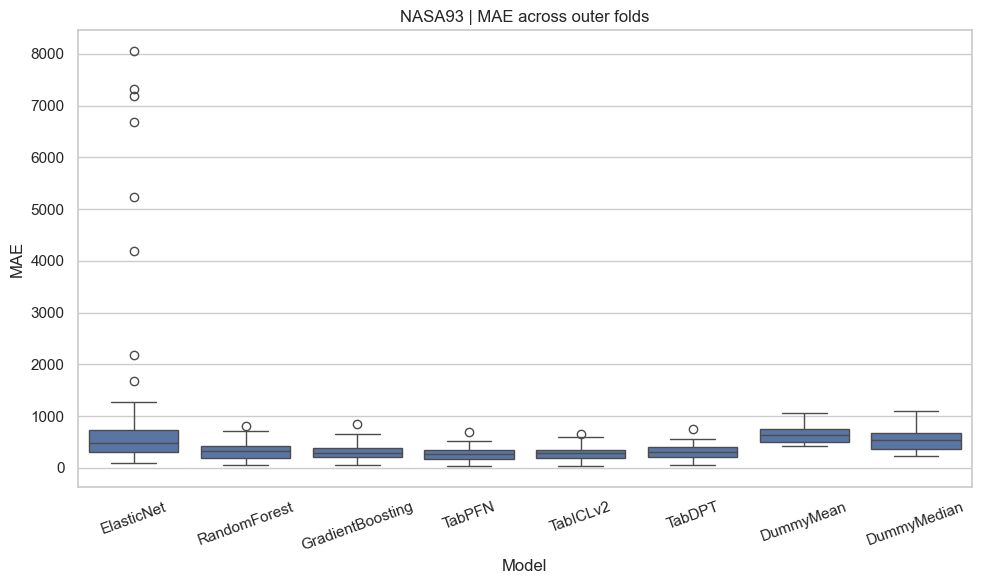

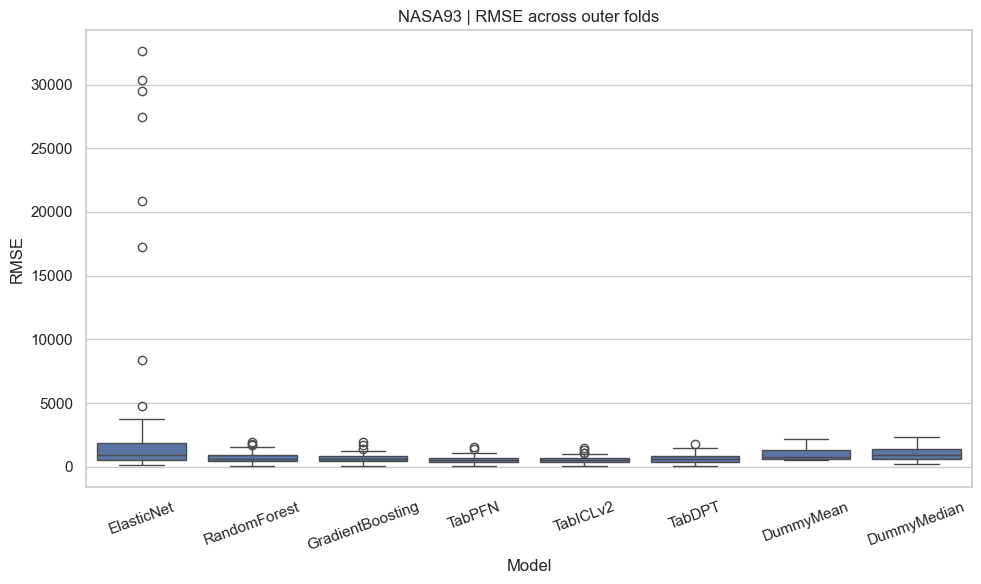

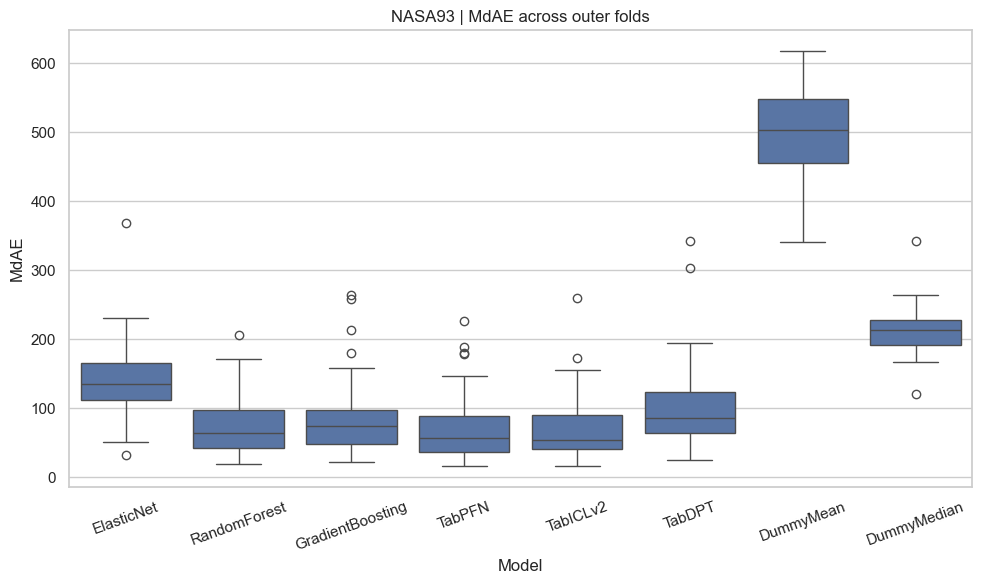

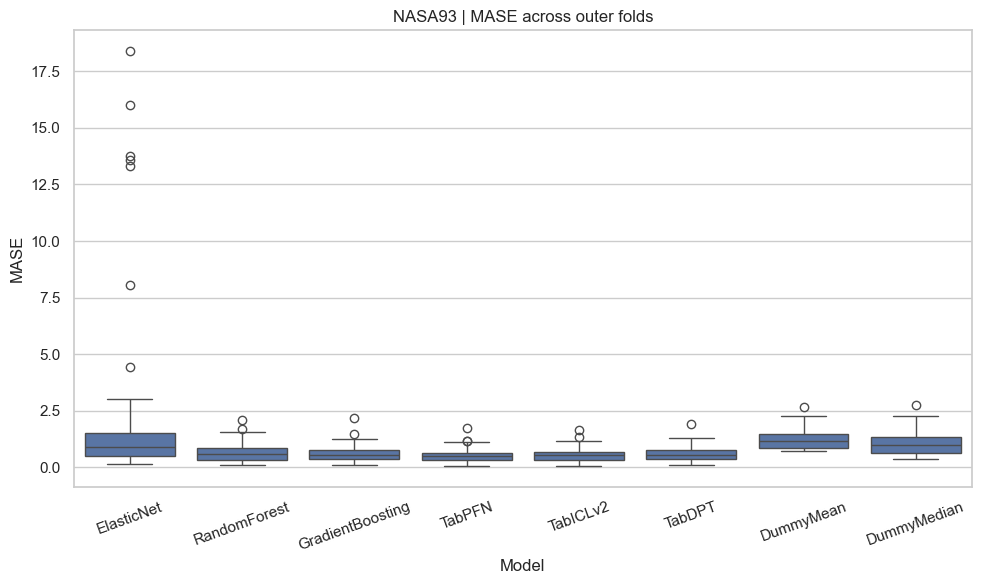

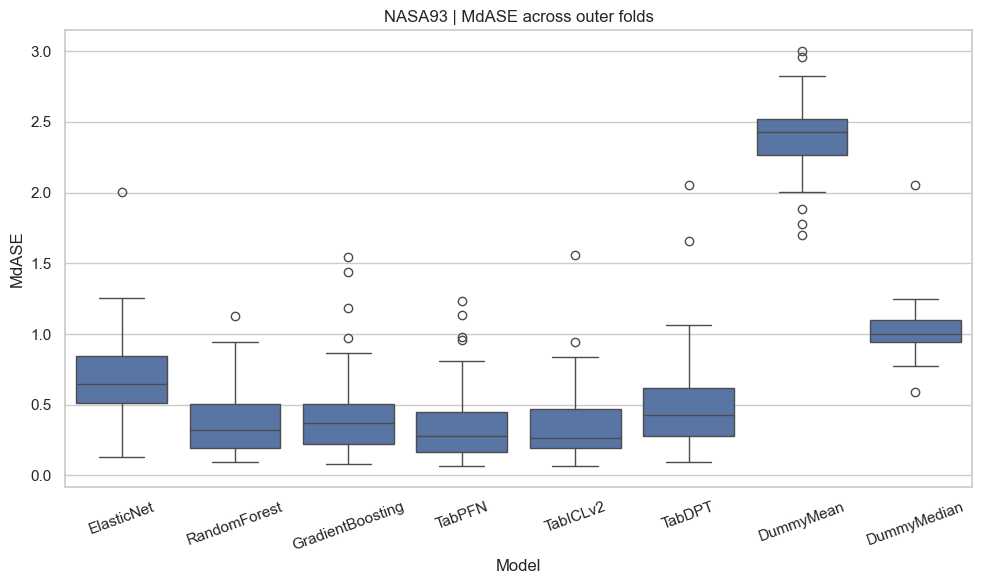

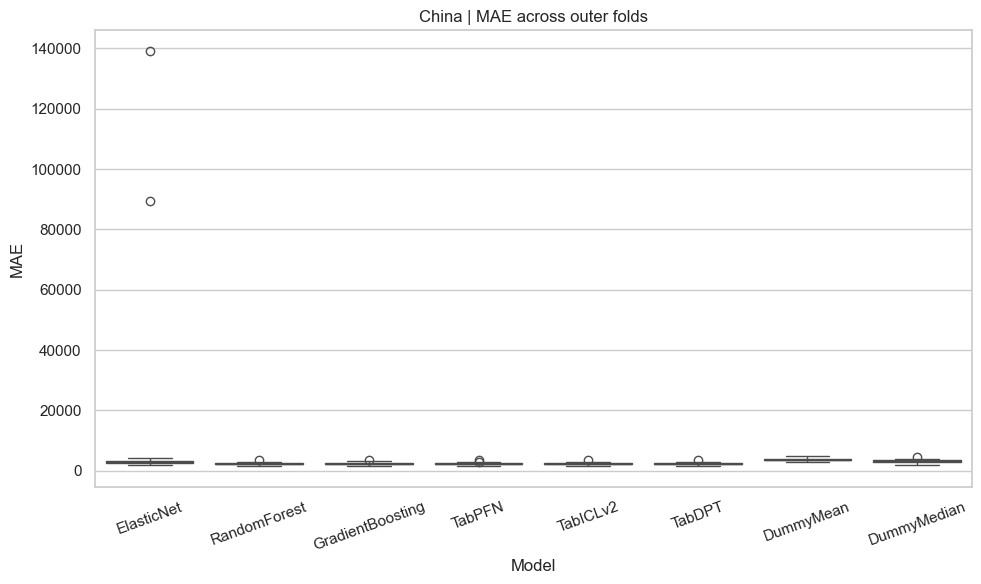

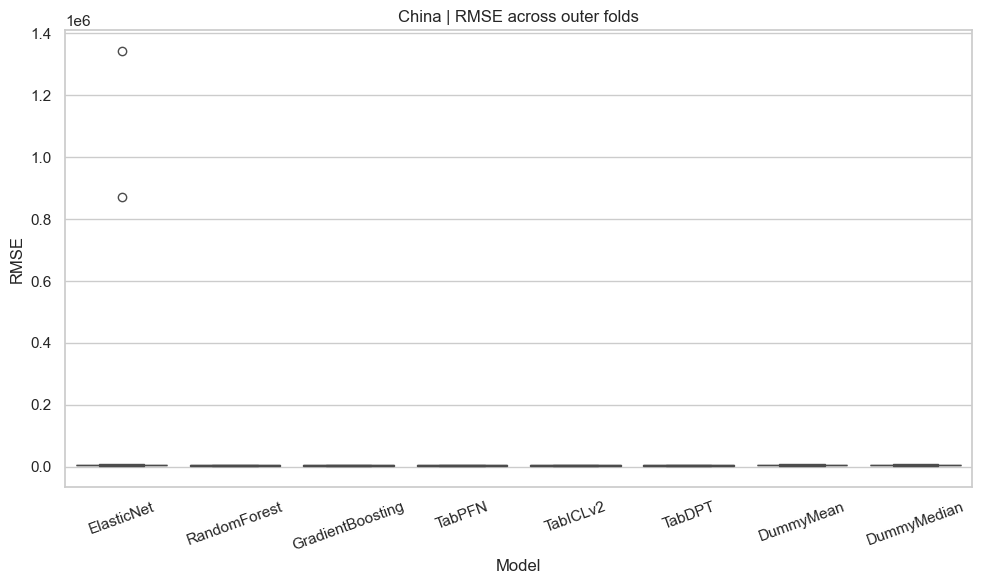

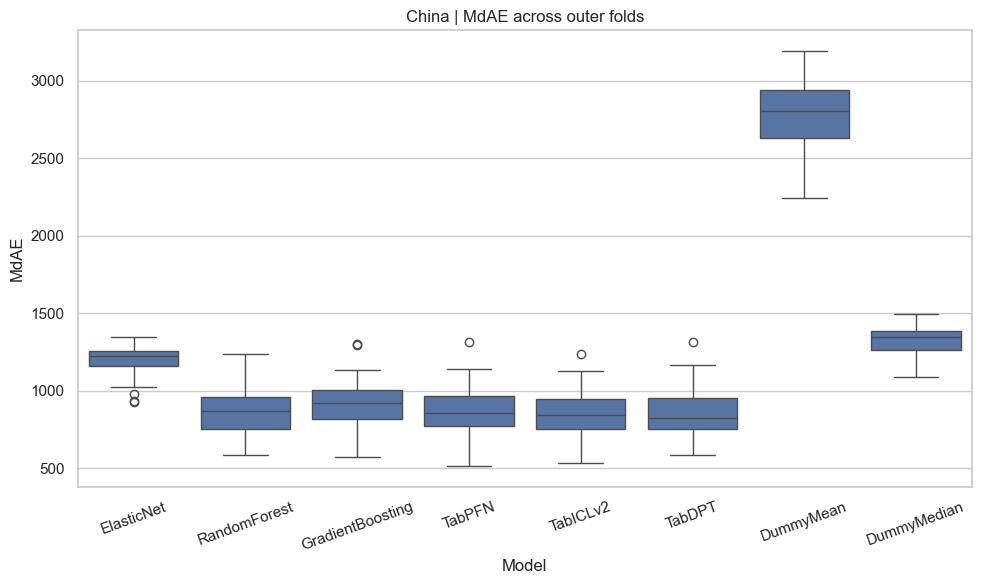

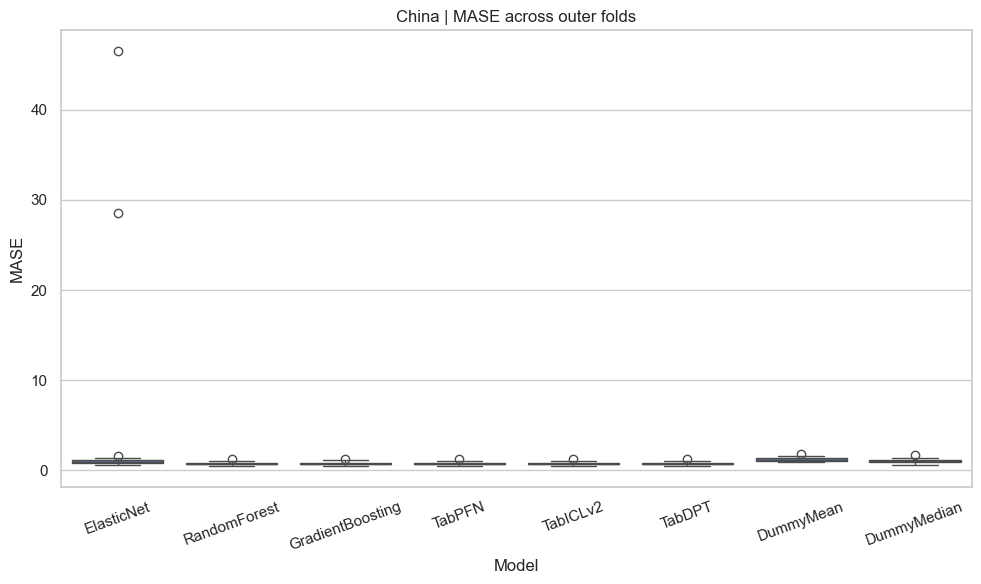

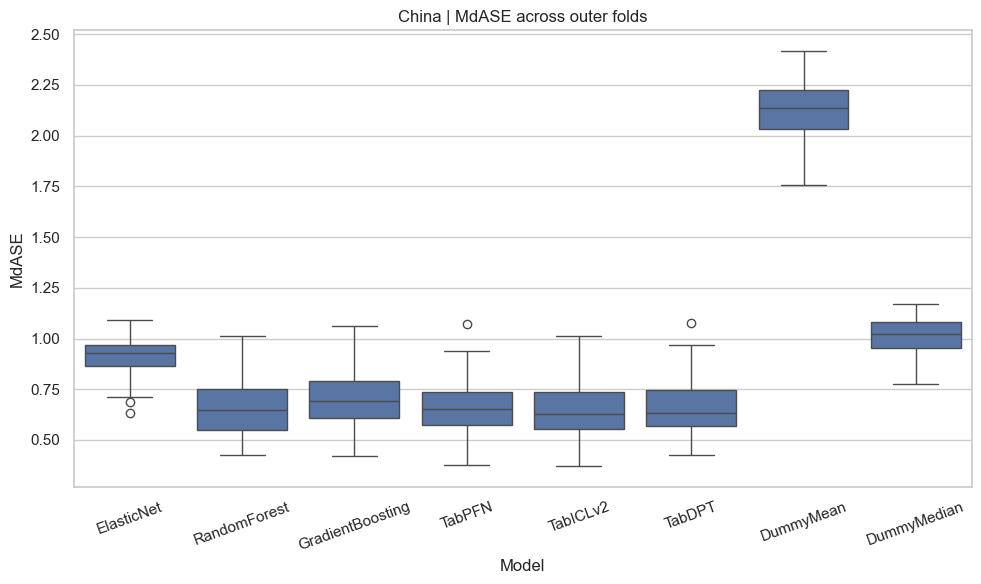

In [13]:
for dataset_name in results_df["dataset"].unique():
    dataset_results = results_df[results_df["dataset"] == dataset_name]

    for metric in metric_cols:
        plt.figure(figsize=(10, 6))
        ax = sns.boxplot(data=dataset_results, x="model", y=metric, order=MODEL_ORDER)
        ax.set_title(f"{dataset_name} | {metric} across outer folds")
        ax.set_xlabel("Model")
        ax.set_ylabel(metric)
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"boxplot_{dataset_name.lower()}_{metric.lower()}.png", dpi=150)
        plt.show()


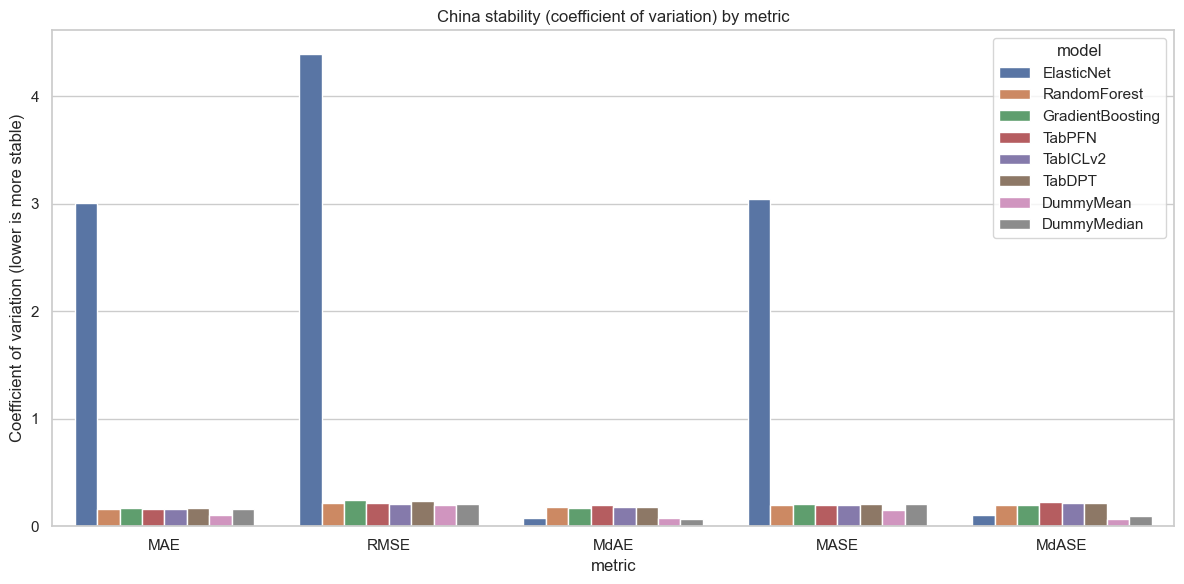

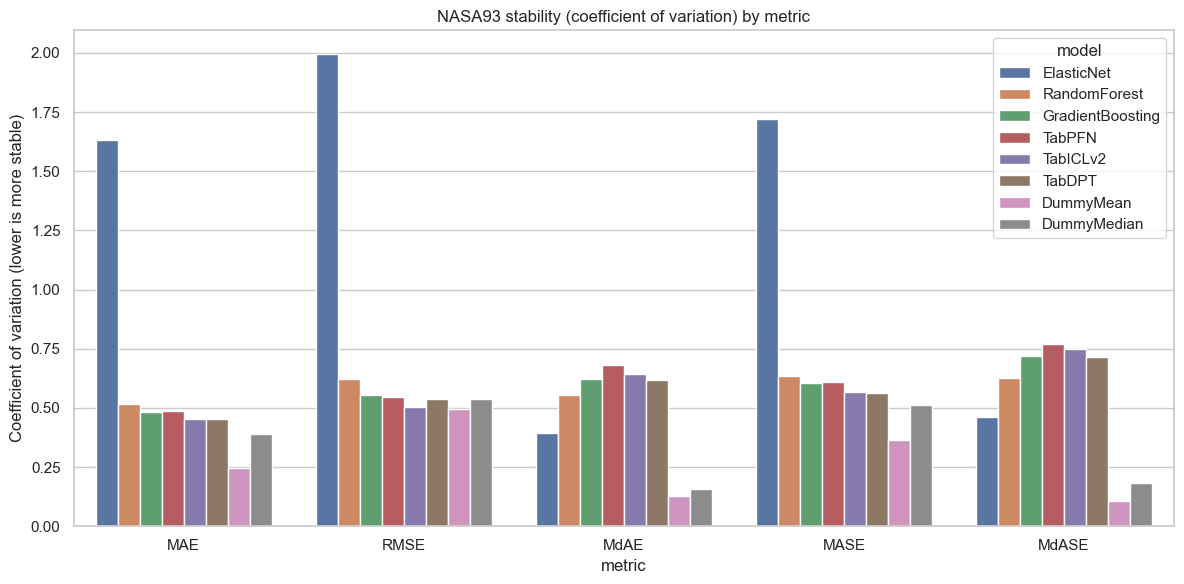

In [14]:
stability_rows = []
for (dataset_name, model_name), g in results_df.groupby(["dataset", "model"]):
    for metric in metric_cols:
        m = g[metric].mean()
        s = g[metric].std(ddof=0)
        cv = s / (m + EPSILON)
        stability_rows.append(
            {
                "dataset": dataset_name,
                "model": model_name,
                "metric": metric,
                "mean": m,
                "std": s,
                "coef_var": cv,
            }
        )

stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv(BASE_DIR / "stability_metrics.csv", index=False)

for dataset_name in stability_df["dataset"].unique():
    dataset_stability = stability_df[stability_df["dataset"] == dataset_name]
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=dataset_stability, x="metric", y="coef_var", hue="model", hue_order=MODEL_ORDER)
    ax.set_title(f"{dataset_name} stability (coefficient of variation) by metric")
    ax.set_ylabel("Coefficient of variation (lower is more stable)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"stability_coefvar_{dataset_name.lower()}.png", dpi=150)
    plt.show()


### Interpretation guide for the plots

After execution, these figures should be read together rather than in isolation. The boxplots reveal whether the apparent winners in the aggregated tables are also consistently strong across folds, or whether their average performance is driven by a small number of especially favorable splits. Wide boxes or long whiskers indicate higher variability, while compact distributions suggest more stable behavior.

The stability charts help confirm that point numerically. Lower coefficients of variation indicate that a model's performance is relatively stable compared with its average error level. When the best-performing model also has low relative variability, the case for selecting it becomes much stronger. If the best average model is noticeably less stable, that trade-off should be discussed explicitly in the final report.

In the final written discussion, the most useful comparisons are: tuned traditional models versus dummy baselines, tabular foundation models versus traditional models, linear versus tree-based approaches, and differences between `NASA93` and `China`. These comparisons connect the plots to the broader methodological question of whether pre-trained tabular predictors add value beyond classical software-effort estimation models.


## 10. Report Support Outputs

This section converts the experimental results into compact artifacts that can be copied directly into the final technical report. The purpose is to reduce friction between the computational analysis and the written deliverable required by the assignment. Instead of manually transcribing results, the notebook exports summary tables in a reusable format.

The table generated here reports average metric values by dataset and model and sorts them in a way that makes comparison easier. Exporting this information as markdown is especially convenient because it can be pasted into a report draft with minimal formatting work. At the same time, keeping the full CSV outputs from previous sections ensures that more detailed analyses remain available if needed.

This approach supports reproducibility and traceability. The report tables are not handwritten summaries produced after the fact; they are direct derivatives of the fold-level evaluation outputs. That makes the reporting pipeline more transparent and reduces the risk of transcription errors or inconsistent result summaries.



In [15]:
summary_for_report = (
    results_df
    .groupby(["dataset", "model"], as_index=False)[metric_cols]
    .mean()
    .round(4)
    .sort_values(["dataset", "MAE", "RMSE"])
)

markdown_table = summary_for_report.to_markdown(index=False)
print(markdown_table)

with open(BASE_DIR / "summary_table.md", "w", encoding="utf-8") as f:
    f.write(markdown_table + "\n")

print("Saved summary markdown table to summary_table.md")



| dataset   | model            |      MAE |      RMSE |      MdAE |   MASE |   MdASE |
|:----------|:-----------------|---------:|----------:|----------:|-------:|--------:|
| China     | TabPFN           | 2295.47  |  4867.05  |  855.941  | 0.7436 |  0.656  |
| China     | TabDPT           | 2301.81  |  4905.52  |  847.059  | 0.7457 |  0.6494 |
| China     | TabICLv2         | 2311.58  |  4942.44  |  851.967  | 0.749  |  0.6532 |
| China     | RandomForest     | 2339.29  |  4962.05  |  863.578  | 0.7579 |  0.6606 |
| China     | GradientBoosting | 2378.3   |  5043.25  |  911.402  | 0.7703 |  0.6978 |
| China     | DummyMedian      | 3118.78  |  6659.17  | 1323.27   | 1.0118 |  1.0093 |
| China     | DummyMean        | 3700.58  |  6362.26  | 2794.51   | 1.1972 |  2.1258 |
| China     | ElasticNet       | 7435.45  | 50262.4   | 1196.61   | 2.4298 |  0.9135 |
| NASA93    | TabPFN           |  267.637 |   562.833 |   69.5986 | 0.529  |  0.3546 |
| NASA93    | TabICLv2         |  283.18  |

## 11. Comparative Analysis: Tabular Foundation Models vs. Traditional Methods

### Motivation for the comparison

This section provides a focused analysis of how the tabular foundation models (`TabPFN`, `TabICLv2`, `TabDPT`) perform relative to the traditional regression and ensemble methods (`ElasticNet`, `RandomForest`, `GradientBoosting`) and the dummy baselines.

The key questions are:

1. **Do tabular foundation models outperform traditional ensemble methods?** Their pre-trained priors may capture regularities that are difficult to learn from small effort-estimation datasets alone.
2. **Are they more stable across folds?** Since they are not tuned through an inner hyperparameter search, they remove one source of split-specific variability, but the results still need to be checked empirically.
3. **When does the approach work best?** `NASA93` has only 93 projects, while `China` is larger and has a richer set of numeric size-related predictors. These regimes may favor different model families.
4. **What are the practical trade-offs?** Foundation models can be accurate but require heavier dependencies, model access, and often stronger hardware than classical sklearn estimators.

### Key observations from the current results

The current exported results show that the tabular foundation models are not just included as an experimental add-on; they are the strongest-performing group overall in this run. On `NASA93`, `TabPFN` has the lowest average `MAE`, `RMSE`, and `MASE`, while `TabICLv2` has the best median-based errors (`MdAE` and `MdASE`). This indicates that the tabular models are especially effective on the smaller dataset, where pre-trained priors can compensate for the limited amount of local training data.

On `China`, the same pattern mostly holds, but the margin is smaller. `TabPFN` is best on the mean-based metrics, while `TabDPT` is best on the median-based metrics. `RandomForest` and `GradientBoosting` remain close competitors, which suggests that the larger `China` dataset gives traditional ensembles enough examples to learn useful dataset-specific structure. The conclusion is therefore not that classical models are obsolete, but that the tabular models provide the best empirical results in this experiment while the ensembles remain strong and simpler alternatives.

The scaled metrics reinforce this interpretation. Values below 1 for `MASE` and `MdASE` show that the serious models improve on a median-based naive reference. The dummy baselines remain important because they reveal the difficulty created by skewed effort distributions: `DummyMedian` is usually much stronger than `DummyMean` on typical absolute error, confirming that central tendency alone is not enough and that the effort targets are not symmetric.

### Interpretation guidelines

When interpreting the results, keep in mind:

- The tabular foundation models use **no inner-loop hyperparameter tuning**, which reduces tuning-related overfitting risk but also limits dataset-specific adaptation.
- Traditional models, especially `RandomForest` and `GradientBoosting`, benefit from **inner-loop `GridSearchCV`**, giving them tailored configurations at the cost of higher tuning expense.
- The **log-target transformation** (`log1p`/`expm1`) is applied consistently to both tuned traditional models and tabular foundation models, so differences are not caused by different treatment of target skewness.
- Stability should be evaluated from the fold distributions and coefficient-of-variation plots, not assumed from the modeling paradigm. In this run, the tabular models are competitive in stability, but they are not uniformly less variable on every dataset and metric.
- Dummy baselines serve as the critical lower bound: any model that does not consistently outperform `DummyMean` and `DummyMedian` provides limited practical value for effort estimation.


In [ ]:
# ── Focused comparison: tabular foundation models vs traditional methods ──────────
# This cell summarizes the comparison between traditional models,
# tabular foundation models, and dummy baselines. It does not retrain models;
# it reuses the fold-level results already computed above.

traditional_models = ["ElasticNet", "RandomForest", "GradientBoosting"]
tabular_foundation_models = ["TabPFN", "TabICLv2", "TabDPT"]
baseline_models = ["DummyMean", "DummyMedian"]

available_models = results_df["model"].unique().tolist()
traditional_available = [m for m in traditional_models if m in available_models]
tabular_available = [m for m in tabular_foundation_models if m in available_models]
baseline_available = [m for m in baseline_models if m in available_models]

print(f"Traditional models evaluated: {traditional_available}")
print(f"Tabular foundation models evaluated: {tabular_available}")
print(f"Baseline models evaluated: {baseline_available}")
print()


def categorize_model(name: str) -> str:
    if name in tabular_foundation_models:
        return "Tabular foundation"
    if name in traditional_models:
        return "Traditional"
    return "Baseline"


results_categorized = results_df.copy()
results_categorized["category"] = results_categorized["model"].apply(categorize_model)

category_order = ["Baseline", "Traditional", "Tabular foundation"]
category_summary = (
    results_categorized
    .groupby(["dataset", "category"], as_index=False)[metric_cols]
    .agg(["mean", "median", "std"])
)
category_summary.columns = ["_".join(col).strip("_") for col in category_summary.columns]
category_summary = category_summary.sort_values(["dataset", "MAE_mean", "RMSE_mean"])

print("=== Performance by Model Category ===")
display(category_summary.round(4))
category_summary.to_csv(BASE_DIR / "category_comparison_summary.csv", index=False)
print("Saved category comparison summary to category_comparison_summary.csv")
print()

model_mean_summary = (
    results_df
    .groupby(["dataset", "model"], as_index=False)[metric_cols]
    .mean()
)

best_by_metric_rows = []
for dataset_name, dataset_results in model_mean_summary.groupby("dataset"):
    for metric in metric_cols:
        best_row = dataset_results.loc[dataset_results[metric].idxmin()]
        best_by_metric_rows.append(
            {
                "dataset": dataset_name,
                "metric": metric,
                "best_model": best_row["model"],
                "category": categorize_model(best_row["model"]),
                "mean_value": best_row[metric],
            }
        )

best_by_metric_df = pd.DataFrame(best_by_metric_rows)
print("=== Best Model by Dataset and Metric (Mean Across Outer Folds) ===")
display(best_by_metric_df.round({"mean_value": 4}))

if tabular_available:
    for ds_name in results_df["dataset"].unique():
        ds_data = results_categorized[results_categorized["dataset"] == ds_name]
        present_categories = [c for c in category_order if c in ds_data["category"].unique()]

        fig, axes = plt.subplots(1, len(metric_cols), figsize=(5 * len(metric_cols), 5))
        fig.suptitle(f"{ds_name}: model-family comparison", fontsize=14, fontweight="bold")

        for idx, metric in enumerate(metric_cols):
            ax = axes[idx] if len(metric_cols) > 1 else axes
            sns.boxplot(
                data=ds_data,
                x="category",
                y=metric,
                ax=ax,
                order=present_categories,
            )
            ax.set_title(metric)
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=25)

        plt.tight_layout()
        fig.savefig(FIGURES_DIR / f"{ds_name}_tabular_vs_traditional.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved comparison figure for {ds_name}")
        print()
else:
    print("No tabular foundation models were available for comparison.")
    print("Install/configure tabpfn, tabicl, and/or tabdpt to enable this analysis.")


### Summary and practical recommendations

The focused comparison shows that the tabular foundation models are the strongest family in the current results. On `NASA93`, they clearly outperform both traditional ensembles and dummy baselines on the average error metrics, and `TabICLv2` is also the strongest model for the median-based metrics. This supports the idea that pre-trained tabular priors are valuable when the local effort-estimation dataset is very small.

On `China`, the tabular models still lead the ranking, but the gap over `RandomForest` and `GradientBoosting` is narrow. This is an important practical point: when a dataset is larger and contains many informative size-related predictors, classical ensembles can learn strong dataset-specific relationships and remain highly competitive. In a production or teaching context, `RandomForest` may therefore still be attractive because it is easier to install, easier to run, and easier to explain than the tabular foundation models.

`ElasticNet` remains useful as a methodological reference because it shows the limitation of a regularized linear additive model on these data. Its median-based errors are not always disastrous, which means it often captures some useful signal, but its mean-based metrics and especially `RMSE` are badly affected by difficult folds and extreme projects. This pattern is consistent with the skewness and outlier structure identified during the exploratory audit.

The dummy baselines confirm that the evaluation is meaningful. `DummyMedian` is generally stronger than `DummyMean`, which is expected for skewed effort distributions. However, all serious non-linear and tabular models improve clearly over the dummy baselines, so the final comparison is not merely showing different ways of reproducing the central tendency of effort.

The practical recommendation is therefore conditional. If the goal is best empirical accuracy in this notebook and the tabular dependencies are available, `TabPFN` is the strongest default choice because it leads the mean-based metrics on both datasets. If the priority is robust typical error, `TabICLv2` on `NASA93` and `TabDPT` on `China` deserve attention because they lead the median-based metrics. If the priority is simplicity, interpretability, and lightweight execution, `RandomForest` remains the strongest traditional alternative.


## 12. Final Conclusions

This study satisfies the assignment objective of building, comparing, and critically evaluating software effort estimation models on two public datasets under a rigorous validation protocol. The final evidence comes from repeated outer cross-validation, with nested hyperparameter tuning for the traditional models that require it. The reported scores therefore reflect out-of-sample performance rather than optimistic resubstitution results.

The main conclusion changes once the three tabular foundation models are included in the comparison. The strongest overall results now come from the tabular foundation family rather than from the classical tree ensembles. On `NASA93`, `TabPFN` achieves the best average `MAE`, `RMSE`, and `MASE`, while `TabICLv2` obtains the best median-based metrics (`MdAE` and `MdASE`). This means that `TabPFN` gives the strongest average accuracy, whereas `TabICLv2` is slightly better for the typical fold-level absolute error. On `China`, `TabPFN` is best on the mean-based metrics and `TabDPT` is best on the median-based metrics. The three tabular models occupy the top ranks on both datasets, showing that pre-trained tabular priors transfer effectively to this software effort-estimation task.

The traditional non-linear ensembles remain important. `RandomForest` and `GradientBoosting` clearly outperform the dummy baselines and are much more reliable than `ElasticNet` on the mean-based metrics. On `China`, their performance is close to the tabular models, which suggests that the larger dataset gives tree ensembles enough information to learn useful dataset-specific relationships. Therefore, the result is not that traditional methods fail, but that the tabular foundation models provide an additional improvement in this run, especially on the smaller `NASA93` dataset.

The comparison across metrics is important because it changes the interpretation slightly. Mean-based metrics (`MAE`, `RMSE`, `MASE`) reward models that keep the full error distribution under control, but they are highly sensitive to very large misses. Median-based metrics (`MdAE`, `MdASE`) emphasize the typical prediction error and are less affected by a small number of extreme folds. This is why the best model depends on the practical objective: `TabPFN` is the best default when average accuracy is prioritized, while `TabICLv2` or `TabDPT` can be preferred when the median absolute error is the main concern.

`ElasticNet` is the weakest tuned model in the final comparison, especially on the mean-based metrics, and the reason is not simply that it is a linear model. The audit already shows strong target skewness, substantial outliers, and in `China` several highly correlated size-related predictors such as `AFP`, `Added`, `Input`, and `File`. Even after regularization and the internal log transform of the target, a linear additive model remains limited when the relationship between effort and the predictors is non-linear, interaction-heavy, or dominated by a few extreme projects. This explains the pattern observed in the results: `ElasticNet` is not uniformly poor on median metrics, so it can still make acceptable predictions on many folds, but it occasionally fails badly enough to produce very large `RMSE`, `MAE`, and `MASE` values.

The outliers and strong right skewness are therefore central to the interpretation of the experiment. In both datasets the effort distribution is concentrated on smaller and medium projects with a long upper tail of expensive projects. Under these conditions, mean-based baselines such as `DummyMean` become fragile, while the median baseline is noticeably stronger. The good performance of `DummyMedian` relative to `DummyMean` confirms that the data are not symmetric. It also justifies the use of robust error metrics and the decision to fit the serious models through `log1p(y)` while still reporting all final metrics on the original effort scale.

From a practical project-management perspective, the safest recommendation depends on the deployment constraints. If the required tabular-model dependencies, model access, and hardware are available, `TabPFN` is the strongest general recommendation because it gives the best average performance on both datasets. If the objective is the most robust typical error, the median-based winners should be considered: `TabICLv2` for `NASA93` and `TabDPT` for `China`. If the priority is a lightweight, easier-to-explain model that can be run in a standard sklearn environment, `RandomForest` is the strongest traditional fallback.

Overall, the notebook supports a defensible final conclusion: the implemented workflow is methodologically sound, the validation strategy is rigorous, the leakage controls are appropriate, and the results are coherent with the statistical structure of the data. The broader lesson is that software effort estimation benefits from models that can handle skewness, predictor interactions, and heterogeneous project structure. In this experiment, tabular foundation models handle those challenges best, while tree-based ensembles remain strong practical alternatives and dummy baselines provide the necessary lower-bound reference.


## 13. References

- NASA93 dataset (PROMISE/Zenodo): https://zenodo.org/records/268419
- China dataset (PROMISE/Zenodo): https://zenodo.org/records/268446
- COC81 DEM fallback candidate (PROMISE/Zenodo): https://zenodo.org/records/268424
- Assignment metrics guidance: MAE, RMSE, MdAE, MASE, MdASE
- TabPFN package/project documentation: https://github.com/PriorLabs/TabPFN
- TabICL package/project documentation: https://github.com/soda-inria/tabicl
- TabDPT package/project documentation: https://github.com/layer6ai-labs/TabDPT
